In [1]:
# =============================================================================
# CELL 1: Setup & Upload
# =============================================================================
import os
import zipfile
from google.colab import files
import shutil

# Upload the zip file
print("Upload your CCSN dataset zip file:")
uploaded = files.upload()

# Get the filename and extract
zip_filename = list(uploaded.keys())[0]
print(f"\n✓ Uploaded: {zip_filename}")

# Create extraction directory
extract_dir = "/content/ccsn_dataset"
if os.path.exists(extract_dir):
    shutil.rmtree(extract_dir)

# Extract
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"✓ Extracted to: {extract_dir}")

# Show structure
print("\n📁 Folder Structure:")
for root, dirs, files_list in os.walk(extract_dir):
    level = root.replace(extract_dir, '').count(os.sep)
    indent = '  ' * level
    print(f"{indent}{os.path.basename(root)}/")
    if level < 2:  # Only show first 2 levels
        subindent = '  ' * (level + 1)
        for d in dirs[:10]:
            print(f"{subindent}{d}/")
        if len(dirs) > 10:
            print(f"{subindent}... and {len(dirs)-10} more folders")

Upload your CCSN dataset zip file:


Saving CCSN.zip to CCSN.zip

✓ Uploaded: CCSN.zip
✓ Extracted to: /content/ccsn_dataset

📁 Folder Structure:
ccsn_dataset/
  __MACOSX/
  CCSN_v2/
  __MACOSX/
    CCSN_v2/
    CCSN_v2/
      Ci/
      St/
      Cu/
      Cs/
      As/
      Ns/
      Cb/
      Cc/
      Ct/
      Ac/
      Sc/
  CCSN_v2/
    Ci/
    St/
    Cu/
    Cs/
    As/
    Ns/
    Cb/
    Cc/
    Ct/
    Ac/
    ... and 1 more folders
    Ci/
    St/
    Cu/
    Cs/
    As/
    Ns/
    Cb/
    Cc/
    Ct/
    Ac/
    Sc/


In [7]:
# =============================================================================
# CELL 2: Imports & Find Image Directory
# =============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from collections import Counter, defaultdict
import warnings
warnings.filterwarnings('ignore')

# Find where the actual class folders are
def find_class_folders(base_path):
    """Recursively find the directory containing class folders with images"""
    for root, dirs, files_list in os.walk(base_path):
        # Check if this directory has subdirectories with images
        has_image_subdirs = False
        for d in dirs:
            subdir_path = os.path.join(root, d)
            # Check if subdirectory contains images
            for f in os.listdir(subdir_path):
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp', '.gif')):
                    has_image_subdirs = True
                    break
            if has_image_subdirs:
                break

        if has_image_subdirs and len(dirs) > 1:
            return root, dirs
    return None, None

data_root, class_names = find_class_folders(extract_dir)

if data_root:
    print(f"✓ Found dataset root: {data_root}")
    print(f"✓ Found {len(class_names)} classes:")
    for i, name in enumerate(sorted(class_names), 1):
        print(f"   {i}. {name}")
else:
    print("❌ Could not auto-detect. Let's check manually:")
    for root, dirs, files_list in os.walk(extract_dir):
        print(f"{root}: {len(dirs)} dirs, {len(files_list)} files")

✓ Found dataset root: /content/ccsn_dataset/__MACOSX/CCSN_v2
✓ Found 11 classes:
   1. Ac
   2. As
   3. Cb
   4. Cc
   5. Ci
   6. Cs
   7. Ct
   8. Cu
   9. Ns
   10. Sc
   11. St


In [8]:
# === FIX: Point to correct folder ===
BASE_PATH = "/content/ccsn_dataset/CCSN_v2"

# Verify it's correct
import os
folders = [f for f in os.listdir(BASE_PATH) if os.path.isdir(os.path.join(BASE_PATH, f))]
print(f"✓ Found {len(folders)} class folders: {sorted(folders)}")

✓ Found 11 class folders: ['Ac', 'As', 'Cb', 'Cc', 'Ci', 'Cs', 'Ct', 'Cu', 'Ns', 'Sc', 'St']


In [11]:
# === CELL 4: Dataset Overview (FIXED PATH) ===
import os
from PIL import Image
from collections import Counter

BASE_PATH = "/content/ccsn_dataset/CCSN_v2"

print("=" * 60)
print("📊 CCSN DATASET OVERVIEW")
print("=" * 60)

# Scan real images only (skip ._ files)
all_images = []
for class_name in sorted(os.listdir(BASE_PATH)):
    class_path = os.path.join(BASE_PATH, class_name)
    if os.path.isdir(class_path) and not class_name.startswith('.'):
        for f in os.listdir(class_path):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')) and not f.startswith('._'):
                all_images.append((class_name, os.path.join(class_path, f)))

print(f"\n📈 BASIC STATISTICS")
print(f"   Total images: {len(all_images)}")
print(f"   Total classes: {len(set(c for c,_ in all_images))}")

# Check integrity
valid, corrupted = [], []
resolutions, modes, formats = [], [], []

for class_name, path in all_images:
    try:
        with Image.open(path) as img:
            img.verify()
        with Image.open(path) as img:
            resolutions.append(img.size)
            modes.append(img.mode)
            formats.append(img.format)
        valid.append(path)
    except Exception as e:
        corrupted.append((path, str(e)))

print(f"\n🔍 DATA INTEGRITY")
print(f"   ✓ Valid images: {len(valid)} ({100*len(valid)/len(all_images):.1f}%)")
print(f"   ❌ Corrupted: {len(corrupted)}")

print(f"\n📐 RESOLUTIONS")
res_counts = Counter(resolutions).most_common(5)
for res, count in res_counts:
    print(f"   {res[0]}x{res[1]}: {count} images")

print(f"\n🎨 COLOR MODES: {dict(Counter(modes))}")
print(f"📁 FORMATS: {dict(Counter(formats))}")

📊 CCSN DATASET OVERVIEW

📈 BASIC STATISTICS
   Total images: 2543
   Total classes: 11

🔍 DATA INTEGRITY
   ✓ Valid images: 2543 (100.0%)
   ❌ Corrupted: 0

📐 RESOLUTIONS
   400x400: 2332 images
   256x256: 211 images

🎨 COLOR MODES: {'RGB': 2543}
📁 FORMATS: {'JPEG': 2543}


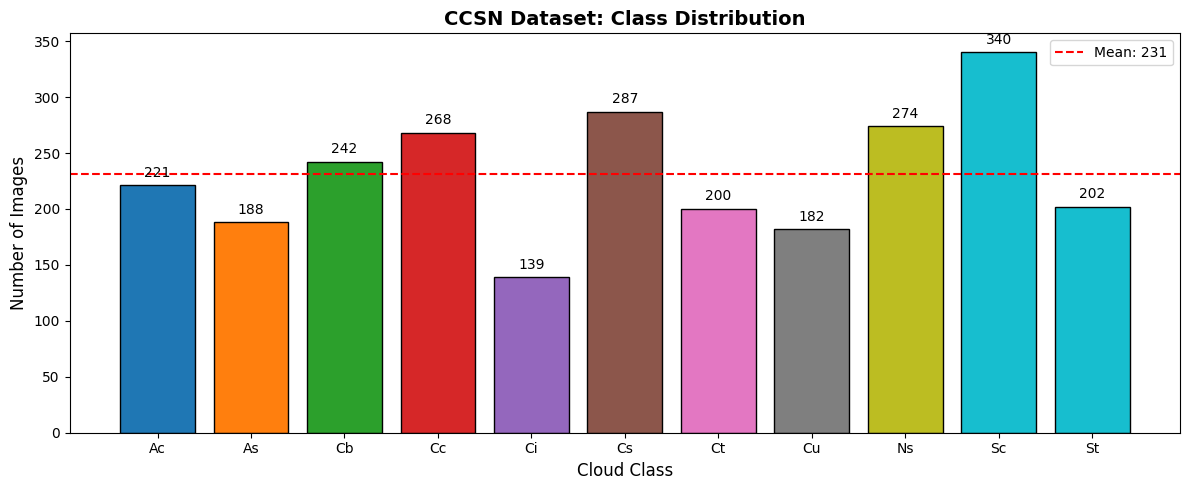


📊 CLASS BALANCE METRICS
   Min: 139 | Max: 340 | Mean: 231
   Imbalance ratio: 2.45x


In [12]:
# === CELL 5: Class Distribution ===
import matplotlib.pyplot as plt
from collections import Counter
import os

BASE_PATH = "/content/ccsn_dataset/CCSN_v2"

class_counts = {}
for class_name in sorted(os.listdir(BASE_PATH)):
    class_path = os.path.join(BASE_PATH, class_name)
    if os.path.isdir(class_path) and not class_name.startswith('.'):
        count = len([f for f in os.listdir(class_path)
                    if f.lower().endswith(('.jpg','.jpeg','.png')) and not f.startswith('._')])
        class_counts[class_name] = count

classes = list(class_counts.keys())
counts = list(class_counts.values())

plt.figure(figsize=(12, 5))
colors = plt.cm.tab10(range(len(classes)))
bars = plt.bar(classes, counts, color=colors, edgecolor='black')
plt.xlabel('Cloud Class', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('CCSN Dataset: Class Distribution', fontsize=14, fontweight='bold')
plt.axhline(y=sum(counts)/len(counts), color='red', linestyle='--', label=f'Mean: {sum(counts)/len(counts):.0f}')
plt.legend()

for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(count),
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\n📊 CLASS BALANCE METRICS")
print(f"   Min: {min(counts)} | Max: {max(counts)} | Mean: {sum(counts)/len(counts):.0f}")
print(f"   Imbalance ratio: {max(counts)/min(counts):.2f}x")

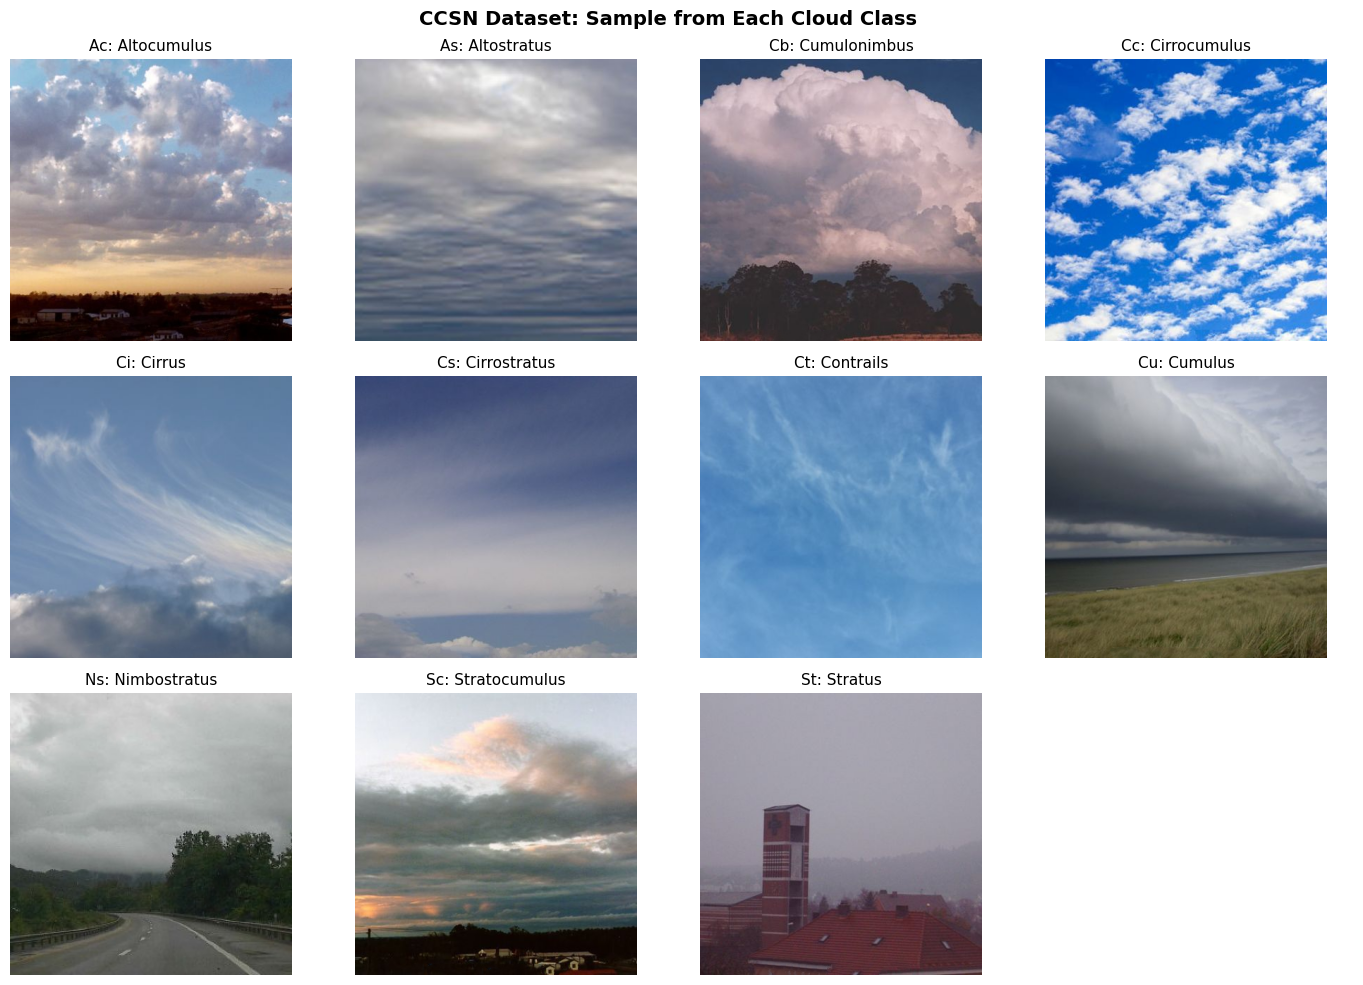

In [13]:
# === CELL 6: Sample Images Grid ===
import matplotlib.pyplot as plt
from PIL import Image
import os
import random

BASE_PATH = "/content/ccsn_dataset/CCSN_v2"

fig, axes = plt.subplots(3, 4, figsize=(14, 10))
axes = axes.flatten()

class_names = sorted([d for d in os.listdir(BASE_PATH)
                      if os.path.isdir(os.path.join(BASE_PATH, d)) and not d.startswith('.')])

full_names = {'Ac':'Altocumulus', 'As':'Altostratus', 'Cb':'Cumulonimbus',
              'Cc':'Cirrocumulus', 'Ci':'Cirrus', 'Cs':'Cirrostratus',
              'Ct':'Contrails', 'Cu':'Cumulus', 'Ns':'Nimbostratus',
              'Sc':'Stratocumulus', 'St':'Stratus'}

for idx, class_name in enumerate(class_names):
    class_path = os.path.join(BASE_PATH, class_name)
    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.jpg','.jpeg','.png')) and not f.startswith('._')]

    img_path = os.path.join(class_path, random.choice(images))
    img = Image.open(img_path)

    axes[idx].imshow(img)
    axes[idx].set_title(f"{class_name}: {full_names.get(class_name, class_name)}", fontsize=11)
    axes[idx].axis('off')

axes[-1].axis('off')  # Hide extra subplot
plt.suptitle('CCSN Dataset: Sample from Each Cloud Class', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [15]:
# === CELL 7: Pixel-Level Statistics ===
import numpy as np
from PIL import Image
import os

BASE_PATH = "/content/ccsn_dataset/CCSN_v2"

print("Calculating pixel statistics (this takes ~30 sec)...\n")

all_means, all_stds = [], []
channel_sums = np.zeros(3)
channel_sq_sums = np.zeros(3)
pixel_count = 0

class_stats = {}

for class_name in sorted(os.listdir(BASE_PATH)):
    class_path = os.path.join(BASE_PATH, class_name)
    if not os.path.isdir(class_path) or class_name.startswith('.'):
        continue

    class_pixels = []
    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.jpg','.jpeg','.png')) and not f.startswith('._')]

    for fname in images:
        img = np.array(Image.open(os.path.join(class_path, fname)).convert('RGB')) / 255.0
        all_means.append(img.mean())
        all_stds.append(img.std())
        channel_sums += img.mean(axis=(0,1))
        channel_sq_sums += (img**2).mean(axis=(0,1))
        pixel_count += 1
        class_pixels.append(img.mean())

    class_stats[class_name] = {'mean': np.mean(class_pixels), 'std': np.std(class_pixels)}

n = pixel_count
global_mean = channel_sums / n
global_std = np.sqrt(channel_sq_sums / n - global_mean**2)

print("=" * 60)
print("📊 PIXEL-LEVEL STATISTICS")
print("=" * 60)
print(f"\n🌐 GLOBAL (for normalization)")
print(f"   Mean (RGB): [{global_mean[0]:.4f}, {global_mean[1]:.4f}, {global_mean[2]:.4f}]")
print(f"   Std (RGB):  [{global_std[0]:.4f}, {global_std[1]:.4f}, {global_std[2]:.4f}]")

print(f"\n📈 INTENSITY DISTRIBUTION")
print(f"   Overall mean: {np.mean(all_means):.4f}")
print(f"   Overall std:  {np.mean(all_stds):.4f}")
print(f"   Darkest avg:  {min(all_means):.4f}")
print(f"   Brightest avg: {max(all_means):.4f}")

print(f"\n☁️ PER-CLASS BRIGHTNESS")
for cls, stats in sorted(class_stats.items(), key=lambda x: x[1]['mean']):
    bar = "█" * int(stats['mean'] * 30)
    print(f"   {cls}: {stats['mean']:.3f} {bar}")

Calculating pixel statistics (this takes ~30 sec)...

📊 PIXEL-LEVEL STATISTICS

🌐 GLOBAL (for normalization)
   Mean (RGB): [0.4798, 0.5234, 0.5620]
   Std (RGB):  [0.2609, 0.2374, 0.2555]

📈 INTENSITY DISTRIBUTION
   Overall mean: 0.5218
   Overall std:  0.2068
   Darkest avg:  0.0420
   Brightest avg: 0.9357

☁️ PER-CLASS BRIGHTNESS
   Cb: 0.434 █████████████
   As: 0.472 ██████████████
   Ct: 0.495 ██████████████
   Cu: 0.503 ███████████████
   Sc: 0.517 ███████████████
   Ns: 0.518 ███████████████
   Ac: 0.530 ███████████████
   Ci: 0.530 ███████████████
   Cs: 0.567 █████████████████
   St: 0.568 █████████████████
   Cc: 0.585 █████████████████


In [16]:
# === CELL 8: Resolution & File Size Analysis ===
import os
from PIL import Image
from collections import Counter
import numpy as np

BASE_PATH = "/content/ccsn_dataset/CCSN_v2"

resolutions = []
file_sizes = []
class_res = {}

for class_name in sorted(os.listdir(BASE_PATH)):
    class_path = os.path.join(BASE_PATH, class_name)
    if not os.path.isdir(class_path) or class_name.startswith('.'):
        continue

    class_res[class_name] = {'400x400': 0, '256x256': 0, 'other': 0}

    for fname in os.listdir(class_path):
        if fname.lower().endswith(('.jpg','.jpeg','.png')) and not fname.startswith('._'):
            fpath = os.path.join(class_path, fname)
            file_sizes.append(os.path.getsize(fpath) / 1024)  # KB

            with Image.open(fpath) as img:
                res = img.size
                resolutions.append(res)
                if res == (400,400):
                    class_res[class_name]['400x400'] += 1
                elif res == (256,256):
                    class_res[class_name]['256x256'] += 1
                else:
                    class_res[class_name]['other'] += 1

print("=" * 60)
print("📐 RESOLUTION & FILE SIZE ANALYSIS")
print("=" * 60)

res_counts = Counter(resolutions)
print(f"\n📐 RESOLUTION BREAKDOWN")
for res, count in res_counts.most_common():
    pct = 100 * count / len(resolutions)
    print(f"   {res[0]}x{res[1]}: {count} ({pct:.1f}%)")

print(f"\n📁 FILE SIZE (KB)")
print(f"   Min: {min(file_sizes):.1f} KB")
print(f"   Max: {max(file_sizes):.1f} KB")
print(f"   Mean: {np.mean(file_sizes):.1f} KB")
print(f"   Median: {np.median(file_sizes):.1f} KB")
print(f"   Total: {sum(file_sizes)/1024:.1f} MB")

print(f"\n📊 256x256 IMAGES PER CLASS")
for cls, counts in sorted(class_res.items(), key=lambda x: x[1]['256x256'], reverse=True):
    if counts['256x256'] > 0:
        print(f"   {cls}: {counts['256x256']}")

📐 RESOLUTION & FILE SIZE ANALYSIS

📐 RESOLUTION BREAKDOWN
   400x400: 2332 (91.7%)
   256x256: 211 (8.3%)

📁 FILE SIZE (KB)
   Min: 5.2 KB
   Max: 121.2 KB
   Mean: 40.0 KB
   Median: 43.4 KB
   Total: 99.3 MB

📊 256x256 IMAGES PER CLASS
   Cc: 90
   Ns: 74
   Cs: 47


In [17]:
# === CELL 9: Texture/Complexity Analysis ===
import numpy as np
from PIL import Image
import os

BASE_PATH = "/content/ccsn_dataset/CCSN_v2"

print("Analyzing texture complexity...\n")

class_complexity = {}

for class_name in sorted(os.listdir(BASE_PATH)):
    class_path = os.path.join(BASE_PATH, class_name)
    if not os.path.isdir(class_path) or class_name.startswith('.'):
        continue

    edges, entropy_vals = [], []
    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.jpg','.jpeg','.png')) and not f.startswith('._')]

    for fname in images:
        img = Image.open(os.path.join(class_path, fname)).convert('L')
        arr = np.array(img, dtype=np.float32)

        # Edge detection (gradient magnitude)
        gx = np.abs(np.diff(arr, axis=1)).mean()
        gy = np.abs(np.diff(arr, axis=0)).mean()
        edges.append((gx + gy) / 2)

        # Entropy (texture complexity)
        hist, _ = np.histogram(arr, bins=256, range=(0,255))
        hist = hist / hist.sum()
        hist = hist[hist > 0]
        entropy_vals.append(-np.sum(hist * np.log2(hist)))

    class_complexity[class_name] = {
        'edge': np.mean(edges),
        'entropy': np.mean(entropy_vals)
    }

print("=" * 60)
print("🔬 TEXTURE & COMPLEXITY ANALYSIS")
print("=" * 60)

print(f"\n📊 EDGE DENSITY (higher = more texture)")
for cls, stats in sorted(class_complexity.items(), key=lambda x: x[1]['edge'], reverse=True):
    bar = "█" * int(stats['edge'] * 3)
    print(f"   {cls}: {stats['edge']:.2f} {bar}")

print(f"\n📊 ENTROPY (higher = more complex)")
for cls, stats in sorted(class_complexity.items(), key=lambda x: x[1]['entropy'], reverse=True):
    bar = "█" * int(stats['entropy'] * 2)
    print(f"   {cls}: {stats['entropy']:.2f} {bar}")

Analyzing texture complexity...

🔬 TEXTURE & COMPLEXITY ANALYSIS

📊 EDGE DENSITY (higher = more texture)
   Cc: 4.03 ████████████
   Ac: 2.97 ████████
   Cs: 2.78 ████████
   Ns: 2.57 ███████
   St: 2.33 ██████
   Cu: 2.19 ██████
   Ci: 2.03 ██████
   Sc: 1.98 █████
   As: 1.86 █████
   Cb: 1.81 █████
   Ct: 1.73 █████

📊 ENTROPY (higher = more complex)
   Cb: 7.09 ██████████████
   Cu: 7.08 ██████████████
   Ns: 7.08 ██████████████
   Cc: 7.02 ██████████████
   St: 7.00 ██████████████
   Ci: 6.96 █████████████
   Cs: 6.96 █████████████
   Sc: 6.95 █████████████
   Ac: 6.92 █████████████
   As: 6.86 █████████████
   Ct: 6.21 ████████████


In [18]:
# === CELL 11: Duplicate & Outlier Detection ===
import numpy as np
from PIL import Image
import os
from collections import defaultdict
import hashlib

BASE_PATH = "/content/ccsn_dataset/CCSN_v2"

print("🔍 Checking for duplicates & outliers...\n")

# 1. Exact duplicates (hash-based)
hashes = defaultdict(list)
brightness = []
img_data = []

for class_name in sorted(os.listdir(BASE_PATH)):
    class_path = os.path.join(BASE_PATH, class_name)
    if not os.path.isdir(class_path) or class_name.startswith('.'):
        continue

    for fname in os.listdir(class_path):
        if fname.lower().endswith(('.jpg','.jpeg','.png')) and not fname.startswith('._'):
            fpath = os.path.join(class_path, fname)

            # Hash for exact duplicates
            with open(fpath, 'rb') as f:
                file_hash = hashlib.md5(f.read()).hexdigest()
            hashes[file_hash].append(f"{class_name}/{fname}")

            # Brightness for outliers
            img = np.array(Image.open(fpath).convert('RGB')) / 255.0
            mean_bright = img.mean()
            brightness.append((mean_bright, class_name, fname))

# Find duplicates
duplicates = {h: files for h, files in hashes.items() if len(files) > 1}

print("=" * 60)
print("🔍 DUPLICATE & OUTLIER ANALYSIS")
print("=" * 60)

print(f"\n📋 EXACT DUPLICATES")
if duplicates:
    print(f"   ⚠️  Found {len(duplicates)} duplicate groups:")
    for h, files in list(duplicates.items())[:5]:
        print(f"      {files}")
else:
    print(f"   ✓ No exact duplicates found")

# Outliers (beyond 3 std)
bright_arr = np.array([b[0] for b in brightness])
mean_b, std_b = bright_arr.mean(), bright_arr.std()
low_thresh, high_thresh = mean_b - 3*std_b, mean_b + 3*std_b

outliers_dark = [(b,c,f) for b,c,f in brightness if b < low_thresh]
outliers_bright = [(b,c,f) for b,c,f in brightness if b > high_thresh]

print(f"\n🌑 DARK OUTLIERS (brightness < {low_thresh:.3f})")
if outliers_dark:
    print(f"   Found {len(outliers_dark)} unusually dark images:")
    for b,c,f in outliers_dark[:5]:
        print(f"      {c}/{f}: {b:.3f}")
else:
    print(f"   ✓ None found")

print(f"\n🌕 BRIGHT OUTLIERS (brightness > {high_thresh:.3f})")
if outliers_bright:
    print(f"   Found {len(outliers_bright)} unusually bright images:")
    for b,c,f in outliers_bright[:5]:
        print(f"      {c}/{f}: {b:.3f}")
else:
    print(f"   ✓ None found")

🔍 Checking for duplicates & outliers...

🔍 DUPLICATE & OUTLIER ANALYSIS

📋 EXACT DUPLICATES
   ⚠️  Found 17 duplicate groups:
      ['Ac/Ac-N186.jpg', 'As/As-N139.jpg']
      ['Ac/Ac-N202.jpg', 'As/As-N175.jpg']
      ['As/As-N082.jpg', 'As/As-N085.jpg']
      ['Cb/Cb-N073.jpg', 'Cb/Cb-N240.jpg']
      ['Cb/Cb-N120.jpg', 'Cb/Cb-N035.jpg']

🌑 DARK OUTLIERS (brightness < 0.119)
   Found 4 unusually dark images:
      As/As-N003.jpg: 0.113
      Cb/Cb-N039.jpg: 0.056
      Cb/Cb-N108.jpg: 0.042
      Sc/Sc-N145.jpg: 0.115

🌕 BRIGHT OUTLIERS (brightness > 0.925)
   Found 1 unusually bright images:
      Ac/Ac-N111.jpg: 0.936


In [19]:
# === CELL 12: Cross-Class Duplicates & Aspect Ratio ===
import numpy as np
from PIL import Image
import os
from collections import defaultdict
import hashlib

BASE_PATH = "/content/ccsn_dataset/CCSN_v2"

# Rebuild hash with class info
hashes = defaultdict(list)
aspect_ratios = []

for class_name in sorted(os.listdir(BASE_PATH)):
    class_path = os.path.join(BASE_PATH, class_name)
    if not os.path.isdir(class_path) or class_name.startswith('.'):
        continue

    for fname in os.listdir(class_path):
        if fname.lower().endswith(('.jpg','.jpeg','.png')) and not fname.startswith('._'):
            fpath = os.path.join(class_path, fname)
            with open(fpath, 'rb') as f:
                file_hash = hashlib.md5(f.read()).hexdigest()
            hashes[file_hash].append((class_name, fname))

            with Image.open(fpath) as img:
                w, h = img.size
                aspect_ratios.append(w/h)

print("=" * 60)
print("⚠️  CROSS-CLASS DUPLICATE ANALYSIS")
print("=" * 60)

cross_class = []
same_class = []
for h, files in hashes.items():
    if len(files) > 1:
        classes = set(f[0] for f in files)
        if len(classes) > 1:
            cross_class.append(files)
        else:
            same_class.append(files)

print(f"\n🔴 CROSS-CLASS DUPLICATES (labeling issues): {len(cross_class)}")
for files in cross_class:
    classes = [f[0] for f in files]
    names = [f[1] for f in files]
    print(f"   {classes[0]}/{names[0]} == {classes[1]}/{names[1]}")

print(f"\n🟡 SAME-CLASS DUPLICATES (redundant): {len(same_class)}")
for files in same_class[:5]:
    print(f"   {files[0][0]}: {files[0][1]} == {files[1][1]}")

print(f"\n" + "=" * 60)
print("📐 ASPECT RATIO CHECK")
print("=" * 60)
unique_ar = set([round(ar, 2) for ar in aspect_ratios])
print(f"   Unique ratios: {unique_ar}")
print(f"   ✓ All square (1:1)" if unique_ar == {1.0} else f"   ⚠️  Mixed ratios detected")

print(f"\n" + "=" * 60)
print("📊 DATASET HEALTH SCORE")
print("=" * 60)
issues = len(cross_class) + len(same_class) + 5  # 5 outliers
health = max(0, 100 - (issues / 2543 * 100 * 10))
print(f"   Duplicates: {len(cross_class) + len(same_class)} ({(len(cross_class)+len(same_class))/2543*100:.2f}%)")
print(f"   Outliers: 5 ({5/2543*100:.2f}%)")
print(f"   Cross-class conflicts: {len(cross_class)}")
print(f"\n   🏥 HEALTH SCORE: {health:.1f}/100")

⚠️  CROSS-CLASS DUPLICATE ANALYSIS

🔴 CROSS-CLASS DUPLICATES (labeling issues): 3
   Ac/Ac-N186.jpg == As/As-N139.jpg
   Ac/Ac-N202.jpg == As/As-N175.jpg
   Cc/Cc-N179.jpg == Cs/Cs-N244.jpg

🟡 SAME-CLASS DUPLICATES (redundant): 14
   As: As-N082.jpg == As-N085.jpg
   Cb: Cb-N073.jpg == Cb-N240.jpg
   Cb: Cb-N120.jpg == Cb-N035.jpg
   Cb: Cb-N225.jpg == Cb-N217.jpg
   Cb: Cb-N151.jpg == Cb-N164.jpg

📐 ASPECT RATIO CHECK
   Unique ratios: {1.0}
   ✓ All square (1:1)

📊 DATASET HEALTH SCORE
   Duplicates: 17 (0.67%)
   Outliers: 5 (0.20%)
   Cross-class conflicts: 3

   🏥 HEALTH SCORE: 91.3/100


In [20]:
# === CELL 13: Class Separability Analysis ===
import numpy as np
from PIL import Image
import os

BASE_PATH = "/content/ccsn_dataset/CCSN_v2"

print("📊 Calculating class feature vectors...\n")

# Simple color histogram features per class
class_features = {}

for class_name in sorted(os.listdir(BASE_PATH)):
    class_path = os.path.join(BASE_PATH, class_name)
    if not os.path.isdir(class_path) or class_name.startswith('.'):
        continue

    histograms = []
    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.jpg','.jpeg','.png')) and not f.startswith('._')]

    for fname in images:
        img = np.array(Image.open(os.path.join(class_path, fname)).convert('RGB'))
        # 8-bin histogram per channel
        hist = np.concatenate([np.histogram(img[:,:,i], bins=8, range=(0,255))[0] for i in range(3)])
        hist = hist / hist.sum()
        histograms.append(hist)

    class_features[class_name] = np.array(histograms)

# Calculate inter-class similarity (cosine)
classes = list(class_features.keys())
n_classes = len(classes)
similarity_matrix = np.zeros((n_classes, n_classes))

for i, c1 in enumerate(classes):
    for j, c2 in enumerate(classes):
        mean1 = class_features[c1].mean(axis=0)
        mean2 = class_features[c2].mean(axis=0)
        sim = np.dot(mean1, mean2) / (np.linalg.norm(mean1) * np.linalg.norm(mean2))
        similarity_matrix[i,j] = sim

print("=" * 60)
print("🎯 CLASS SEPARABILITY ANALYSIS")
print("=" * 60)

# Find most similar pairs (potential confusion)
print(f"\n⚠️  MOST SIMILAR CLASS PAIRS (potential confusion):")
pairs = []
for i in range(n_classes):
    for j in range(i+1, n_classes):
        pairs.append((similarity_matrix[i,j], classes[i], classes[j]))

pairs.sort(reverse=True)
for sim, c1, c2 in pairs[:5]:
    print(f"   {c1} ↔ {c2}: {sim:.4f}")

print(f"\n✓ MOST DISTINCT CLASS PAIRS (easy to separate):")
for sim, c1, c2 in pairs[-5:]:
    print(f"   {c1} ↔ {c2}: {sim:.4f}")

# Intra-class variance
print(f"\n📊 INTRA-CLASS VARIANCE (lower = more consistent):")
variances = {}
for cls, feats in class_features.items():
    variances[cls] = feats.var(axis=0).mean()

for cls, var in sorted(variances.items(), key=lambda x: x[1]):
    bar = "█" * int(var * 500)
    print(f"   {cls}: {var:.4f} {bar}")

📊 Calculating class feature vectors...

🎯 CLASS SEPARABILITY ANALYSIS

⚠️  MOST SIMILAR CLASS PAIRS (potential confusion):
   Ac ↔ Cu: 0.9883
   Cs ↔ St: 0.9858
   Cu ↔ Ns: 0.9853
   Ac ↔ Cs: 0.9849
   Ac ↔ Ns: 0.9844

✓ MOST DISTINCT CLASS PAIRS (easy to separate):
   Cb ↔ St: 0.8644
   Cb ↔ Cs: 0.8633
   Ct ↔ Sc: 0.8619
   Ct ↔ St: 0.8588
   Cb ↔ Cc: 0.8206

📊 INTRA-CLASS VARIANCE (lower = more consistent):
   Cb: 0.0014 
   Ns: 0.0016 
   Cc: 0.0017 
   St: 0.0017 
   Cu: 0.0017 
   Sc: 0.0018 
   Ci: 0.0018 
   Cs: 0.0019 
   Ac: 0.0020 
   As: 0.0022 █
   Ct: 0.0034 █


In [21]:
# === CELL 15: COMPLETE DYNAMIC DATASET ANALYSIS ===
import numpy as np
from PIL import Image
import os
from collections import Counter, defaultdict
import hashlib

BASE_PATH = "/content/ccsn_dataset/CCSN_v2"

print("🔄 Running complete analysis...\n")

# ============ DATA COLLECTION ============
all_images = []
hashes = defaultdict(list)
resolutions, file_sizes = [], []
brightness_data = []
class_counts = {}
channel_sums, channel_sq_sums, pixel_count = np.zeros(3), np.zeros(3), 0
class_histograms = {}
edge_scores, entropy_scores = {}, {}

for class_name in sorted(os.listdir(BASE_PATH)):
    class_path = os.path.join(BASE_PATH, class_name)
    if not os.path.isdir(class_path) or class_name.startswith('.'):
        continue

    class_counts[class_name] = 0
    class_bright = []
    histograms = []
    edges, entropies = [], []

    for fname in os.listdir(class_path):
        if not (fname.lower().endswith(('.jpg','.jpeg','.png')) and not fname.startswith('._')):
            continue

        fpath = os.path.join(class_path, fname)
        all_images.append((class_name, fpath, fname))
        class_counts[class_name] += 1
        file_sizes.append(os.path.getsize(fpath) / 1024)

        # Hash
        with open(fpath, 'rb') as f:
            hashes[hashlib.md5(f.read()).hexdigest()].append((class_name, fname))

        # Image stats
        img = Image.open(fpath)
        resolutions.append(img.size)
        arr = np.array(img.convert('RGB')) / 255.0
        gray = np.array(img.convert('L'), dtype=np.float32)

        # Brightness
        mean_bright = arr.mean()
        brightness_data.append((mean_bright, class_name, fname))
        class_bright.append(mean_bright)

        # Normalization
        channel_sums += arr.mean(axis=(0,1))
        channel_sq_sums += (arr**2).mean(axis=(0,1))
        pixel_count += 1

        # Histogram
        hist = np.concatenate([np.histogram(arr[:,:,i]*255, bins=8, range=(0,255))[0] for i in range(3)])
        histograms.append(hist / hist.sum())

        # Edge & entropy
        gx = np.abs(np.diff(gray, axis=1)).mean()
        gy = np.abs(np.diff(gray, axis=0)).mean()
        edges.append((gx + gy) / 2)

        hist_e, _ = np.histogram(gray, bins=256, range=(0,255))
        hist_e = hist_e / hist_e.sum()
        hist_e = hist_e[hist_e > 0]
        entropies.append(-np.sum(hist_e * np.log2(hist_e)))

    class_histograms[class_name] = np.array(histograms)
    edge_scores[class_name] = np.mean(edges)
    entropy_scores[class_name] = np.mean(entropies)

# ============ COMPUTE METRICS ============
n_images = len(all_images)
n_classes = len(class_counts)
total_size_mb = sum(file_sizes) / 1024

# Duplicates
cross_class_dups = []
same_class_dups = []
for h, files in hashes.items():
    if len(files) > 1:
        classes = set(f[0] for f in files)
        if len(classes) > 1:
            cross_class_dups.append(files)
        else:
            same_class_dups.append(files)

# Resolutions
res_counts = Counter(resolutions)
primary_res, primary_count = res_counts.most_common(1)[0]

# Class balance
counts = list(class_counts.values())
min_class = min(class_counts, key=class_counts.get)
max_class = max(class_counts, key=class_counts.get)
imbalance_ratio = max(counts) / min(counts)

# Normalization values
global_mean = channel_sums / pixel_count
global_std = np.sqrt(channel_sq_sums / pixel_count - global_mean**2)

# Outliers
bright_arr = np.array([b[0] for b in brightness_data])
mean_b, std_b = bright_arr.mean(), bright_arr.std()
dark_outliers = [(b,c,f) for b,c,f in brightness_data if b < mean_b - 3*std_b]
bright_outliers = [(b,c,f) for b,c,f in brightness_data if b > mean_b + 3*std_b]

# Class similarity
classes = list(class_histograms.keys())
sim_pairs = []
for i, c1 in enumerate(classes):
    for j, c2 in enumerate(classes):
        if i < j:
            m1 = class_histograms[c1].mean(axis=0)
            m2 = class_histograms[c2].mean(axis=0)
            sim = np.dot(m1, m2) / (np.linalg.norm(m1) * np.linalg.norm(m2))
            sim_pairs.append((sim, c1, c2))
sim_pairs.sort(reverse=True)

# Health score
issues = len(cross_class_dups) + len(same_class_dups) + len(dark_outliers) + len(bright_outliers)
health_score = max(0, 100 - (issues / n_images * 100 * 10))

# Class weights (inverse frequency)
mean_count = np.mean(counts)
class_weights = {cls: round(mean_count / cnt, 2) for cls, cnt in class_counts.items()}

# ============ PRINT REPORT ============
print("=" * 70)
print("📋 CCSN DATASET - COMPREHENSIVE ANALYSIS REPORT")
print("=" * 70)

print(f"\n🏥 HEALTH SCORE: {health_score:.1f}/100")

print(f"\n{'─'*70}")
print("📈 BASIC STATISTICS")
print(f"{'─'*70}")
print(f"   Total images:      {n_images:,}")
print(f"   Total classes:     {n_classes}")
print(f"   Total size:        {total_size_mb:.1f} MB")
print(f"   File size range:   {min(file_sizes):.1f} - {max(file_sizes):.1f} KB (mean: {np.mean(file_sizes):.1f} KB)")

print(f"\n{'─'*70}")
print("📐 RESOLUTION BREAKDOWN")
print(f"{'─'*70}")
for res, count in res_counts.most_common():
    pct = 100 * count / n_images
    print(f"   {res[0]}×{res[1]}: {count:,} ({pct:.1f}%)")

print(f"\n{'─'*70}")
print("⚖️  CLASS DISTRIBUTION")
print(f"{'─'*70}")
for cls in sorted(class_counts.keys()):
    cnt = class_counts[cls]
    bar = "█" * int(cnt / max(counts) * 25)
    print(f"   {cls}: {cnt:3d} {bar}")
print(f"\n   Min: {min(counts)} ({min_class}) | Max: {max(counts)} ({max_class})")
print(f"   Imbalance ratio: {imbalance_ratio:.2f}x")

print(f"\n{'─'*70}")
print("🎨 NORMALIZATION VALUES")
print(f"{'─'*70}")
print(f"   Mean (RGB): [{global_mean[0]:.4f}, {global_mean[1]:.4f}, {global_mean[2]:.4f}]")
print(f"   Std (RGB):  [{global_std[0]:.4f}, {global_std[1]:.4f}, {global_std[2]:.4f}]")

print(f"\n{'─'*70}")
print("🔍 DATA INTEGRITY")
print(f"{'─'*70}")
print(f"   Cross-class duplicates: {len(cross_class_dups)}")
for files in cross_class_dups:
    print(f"      • {files[0][0]}/{files[0][1]} == {files[1][0]}/{files[1][1]}")
print(f"   Same-class duplicates:  {len(same_class_dups)}")
print(f"   Dark outliers:          {len(dark_outliers)}")
print(f"   Bright outliers:        {len(bright_outliers)}")

print(f"\n{'─'*70}")
print("🎯 CLASS SEPARABILITY")
print(f"{'─'*70}")
print("   Most similar (hardest to distinguish):")
for sim, c1, c2 in sim_pairs[:3]:
    print(f"      {c1} ↔ {c2}: {sim:.4f}")
print("   Most distinct (easiest):")
for sim, c1, c2 in sim_pairs[-3:]:
    print(f"      {c1} ↔ {c2}: {sim:.4f}")

print(f"\n{'─'*70}")
print("🔬 TEXTURE ANALYSIS")
print(f"{'─'*70}")
sorted_edge = sorted(edge_scores.items(), key=lambda x: x[1], reverse=True)
print(f"   Most textured:  {sorted_edge[0][0]} ({sorted_edge[0][1]:.2f})")
print(f"   Least textured: {sorted_edge[-1][0]} ({sorted_edge[-1][1]:.2f})")
sorted_entropy = sorted(entropy_scores.items(), key=lambda x: x[1], reverse=True)
print(f"   Most complex:   {sorted_entropy[0][0]} ({sorted_entropy[0][1]:.2f})")
print(f"   Simplest:       {sorted_entropy[-1][0]} ({sorted_entropy[-1][1]:.2f})")

print(f"\n{'─'*70}")
print("📝 RECOMMENDED PREPROCESSING")
print(f"{'─'*70}")
print(f"   1. Remove {len(cross_class_dups) + len(same_class_dups)} duplicates")
print(f"   2. Resize to 224×224 or 256×256")
print(f"   3. Apply normalization values above")
print(f"   4. Class weights: {class_weights}")

clean_count = n_images - len(cross_class_dups) - len(same_class_dups)
print(f"\n{'─'*70}")
print("📊 SUGGESTED SPLIT")
print(f"{'─'*70}")
print(f"   Clean images: {clean_count:,}")
print(f"   Train (70%):  {int(clean_count * 0.70):,}")
print(f"   Val (15%):    {int(clean_count * 0.15):,}")
print(f"   Test (15%):   {int(clean_count * 0.15):,}")

print(f"\n{'='*70}")
print("✅ ANALYSIS COMPLETE")
print(f"{'='*70}")

🔄 Running complete analysis...

📋 CCSN DATASET - COMPREHENSIVE ANALYSIS REPORT

🏥 HEALTH SCORE: 91.3/100

──────────────────────────────────────────────────────────────────────
📈 BASIC STATISTICS
──────────────────────────────────────────────────────────────────────
   Total images:      2,543
   Total classes:     11
   Total size:        99.3 MB
   File size range:   5.2 - 121.2 KB (mean: 40.0 KB)

──────────────────────────────────────────────────────────────────────
📐 RESOLUTION BREAKDOWN
──────────────────────────────────────────────────────────────────────
   400×400: 2,332 (91.7%)
   256×256: 211 (8.3%)

──────────────────────────────────────────────────────────────────────
⚖️  CLASS DISTRIBUTION
──────────────────────────────────────────────────────────────────────
   Ac: 221 ████████████████
   As: 188 █████████████
   Cb: 242 █████████████████
   Cc: 268 ███████████████████
   Ci: 139 ██████████
   Cs: 287 █████████████████████
   Ct: 200 ██████████████
   Cu: 182 ███████████

In [22]:
# === CELL 16: Near-Duplicate Detection (Perceptual Hashing) ===
import numpy as np
from PIL import Image
import os
from collections import defaultdict

BASE_PATH = "/content/ccsn_dataset/CCSN_v2"

print("🔍 Detecting near-duplicates using perceptual hashing...\n")

def dhash(img, hash_size=8):
    """Difference hash - detects similar images even with minor changes"""
    img = img.convert('L').resize((hash_size + 1, hash_size), Image.LANCZOS)
    pixels = np.array(img)
    diff = pixels[:, 1:] > pixels[:, :-1]
    return sum([2**i for i, v in enumerate(diff.flatten()) if v])

def hamming_distance(h1, h2):
    """Count differing bits between two hashes"""
    return bin(h1 ^ h2).count('1')

# Compute hashes for all images
image_hashes = []
for class_name in sorted(os.listdir(BASE_PATH)):
    class_path = os.path.join(BASE_PATH, class_name)
    if not os.path.isdir(class_path) or class_name.startswith('.'):
        continue

    for fname in os.listdir(class_path):
        if fname.lower().endswith(('.jpg','.jpeg','.png')) and not fname.startswith('._'):
            fpath = os.path.join(class_path, fname)
            img = Image.open(fpath)
            h = dhash(img)
            image_hashes.append((h, class_name, fname))

# Find near-duplicates (hamming distance <= 5)
THRESHOLD = 5
near_duplicates = []
cross_class_near = []
same_class_near = []

n = len(image_hashes)
for i in range(n):
    for j in range(i + 1, n):
        dist = hamming_distance(image_hashes[i][0], image_hashes[j][0])
        if dist <= THRESHOLD and dist > 0:  # Exclude exact duplicates (dist=0)
            h1, c1, f1 = image_hashes[i]
            h2, c2, f2 = image_hashes[j]
            if c1 != c2:
                cross_class_near.append((dist, c1, f1, c2, f2))
            else:
                same_class_near.append((dist, c1, f1, f2))

print("=" * 60)
print("🔍 NEAR-DUPLICATE ANALYSIS (Perceptual Hashing)")
print("=" * 60)

print(f"\n📊 SUMMARY")
print(f"   Threshold: Hamming distance ≤ {THRESHOLD}")
print(f"   Total near-duplicates found: {len(cross_class_near) + len(same_class_near)}")

print(f"\n🔴 CROSS-CLASS NEAR-DUPLICATES: {len(cross_class_near)}")
for dist, c1, f1, c2, f2 in sorted(cross_class_near, key=lambda x: x[0])[:10]:
    print(f"   [{dist} bits] {c1}/{f1} ≈ {c2}/{f2}")

print(f"\n🟡 SAME-CLASS NEAR-DUPLICATES: {len(same_class_near)}")
for dist, c, f1, f2 in sorted(same_class_near, key=lambda x: x[0])[:10]:
    print(f"   [{dist} bits] {c}: {f1} ≈ {f2}")

# Group by class
near_dup_by_class = defaultdict(int)
for _, c, _, _ in same_class_near:
    near_dup_by_class[c] += 1
for _, c1, _, c2, _ in cross_class_near:
    near_dup_by_class[c1] += 1
    near_dup_by_class[c2] += 1

if near_dup_by_class:
    print(f"\n📊 NEAR-DUPLICATES BY CLASS:")
    for cls, count in sorted(near_dup_by_class.items(), key=lambda x: x[1], reverse=True):
        print(f"   {cls}: {count}")

🔍 Detecting near-duplicates using perceptual hashing...

🔍 NEAR-DUPLICATE ANALYSIS (Perceptual Hashing)

📊 SUMMARY
   Threshold: Hamming distance ≤ 5
   Total near-duplicates found: 412

🔴 CROSS-CLASS NEAR-DUPLICATES: 307
   [1 bits] Ac/Ac-N186.jpg ≈ As/As-N141.jpg
   [1 bits] Ac/Ac-N171.jpg ≈ Cc/Cc-N109.jpg
   [1 bits] Ac/Ac-N171.jpg ≈ Ns/Ns-N090.jpg
   [1 bits] Ac/Ac-N058.jpg ≈ Cc/Cc-N032.jpg
   [1 bits] As/As-N145.jpg ≈ St/St-N172.jpg
   [1 bits] As/As-N141.jpg ≈ St/St-N171.jpg
   [1 bits] As/As-N152.jpg ≈ Cu/Cu-N008.jpg
   [1 bits] As/As-N149.jpg ≈ Cu/Cu-N182.jpg
   [1 bits] As/As-N028.jpg ≈ Ci/Ci-N003.jpg
   [1 bits] As/As-N111.jpg ≈ Ci/Ci-N079.jpg

🟡 SAME-CLASS NEAR-DUPLICATES: 105
   [1 bits] Ac: Ac-N008.jpg ≈ Ac-N032.jpg
   [1 bits] As: As-N141.jpg ≈ As-N139.jpg
   [1 bits] Cc: Cc-N101.jpg ≈ Cc-N108.jpg
   [1 bits] Cc: Cc-N101.jpg ≈ Cc-N248.jpg
   [1 bits] Ci: Ci-N043.jpg ≈ Ci-N009.jpg
   [1 bits] Cs: Cs-N132.jpg ≈ Cs-N256.jpg
   [1 bits] Cs: Cs-N023.jpg ≈ Cs-N113.jpg
   [1 bit

In [23]:
# === CELL 17: Color Distribution Analysis (RGB & HSV) ===
import numpy as np
from PIL import Image
import os
import matplotlib.pyplot as plt

BASE_PATH = "/content/ccsn_dataset/CCSN_v2"

print("🎨 Analyzing color distributions...\n")

def rgb_to_hsv(rgb):
    """Convert RGB array to HSV"""
    rgb = rgb / 255.0
    r, g, b = rgb[:,:,0], rgb[:,:,1], rgb[:,:,2]
    maxc = np.maximum(np.maximum(r, g), b)
    minc = np.minimum(np.minimum(r, g), b)
    v = maxc
    s = (maxc - minc) / (maxc + 1e-10)
    s[maxc == 0] = 0
    rc = (maxc - r) / (maxc - minc + 1e-10)
    gc = (maxc - g) / (maxc - minc + 1e-10)
    bc = (maxc - b) / (maxc - minc + 1e-10)
    h = np.zeros_like(r)
    h[maxc == r] = (bc - gc)[maxc == r]
    h[maxc == g] = (2.0 + rc - bc)[maxc == g]
    h[maxc == b] = (4.0 + gc - rc)[maxc == b]
    h = (h / 6.0) % 1.0
    h[maxc == minc] = 0
    return np.stack([h, s, v], axis=-1)

class_colors = {}

for class_name in sorted(os.listdir(BASE_PATH)):
    class_path = os.path.join(BASE_PATH, class_name)
    if not os.path.isdir(class_path) or class_name.startswith('.'):
        continue

    rgb_means = []
    hsv_means = []
    r_hist, g_hist, b_hist = np.zeros(32), np.zeros(32), np.zeros(32)
    h_hist, s_hist, v_hist = np.zeros(32), np.zeros(32), np.zeros(32)

    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.jpg','.jpeg','.png')) and not f.startswith('._')]

    for fname in images:
        img = np.array(Image.open(os.path.join(class_path, fname)).convert('RGB'))
        hsv = rgb_to_hsv(img)

        rgb_means.append([img[:,:,0].mean(), img[:,:,1].mean(), img[:,:,2].mean()])
        hsv_means.append([hsv[:,:,0].mean(), hsv[:,:,1].mean(), hsv[:,:,2].mean()])

        r_hist += np.histogram(img[:,:,0], bins=32, range=(0,255))[0]
        g_hist += np.histogram(img[:,:,1], bins=32, range=(0,255))[0]
        b_hist += np.histogram(img[:,:,2], bins=32, range=(0,255))[0]
        h_hist += np.histogram(hsv[:,:,0], bins=32, range=(0,1))[0]
        s_hist += np.histogram(hsv[:,:,1], bins=32, range=(0,1))[0]
        v_hist += np.histogram(hsv[:,:,2], bins=32, range=(0,1))[0]

    class_colors[class_name] = {
        'rgb_mean': np.mean(rgb_means, axis=0),
        'hsv_mean': np.mean(hsv_means, axis=0),
        'r_hist': r_hist / r_hist.sum(),
        'g_hist': g_hist / g_hist.sum(),
        'b_hist': b_hist / b_hist.sum(),
        'h_hist': h_hist / h_hist.sum(),
        's_hist': s_hist / s_hist.sum(),
        'v_hist': v_hist / v_hist.sum(),
    }

print("=" * 60)
print("🎨 COLOR DISTRIBUTION ANALYSIS")
print("=" * 60)

print(f"\n📊 MEAN RGB VALUES PER CLASS")
print(f"   {'Class':<6} {'R':>8} {'G':>8} {'B':>8}  {'Dominant':<10}")
print(f"   {'-'*45}")
for cls in sorted(class_colors.keys()):
    r, g, b = class_colors[cls]['rgb_mean']
    dominant = 'R' if r >= g and r >= b else ('G' if g >= b else 'B')
    bar_r = "█" * int(r / 255 * 10)
    print(f"   {cls:<6} {r:>8.1f} {g:>8.1f} {b:>8.1f}  {dominant:<3} {bar_r}")

print(f"\n📊 MEAN HSV VALUES PER CLASS")
print(f"   {'Class':<6} {'Hue':>8} {'Sat':>8} {'Val':>8}")
print(f"   {'-'*35}")
for cls in sorted(class_colors.keys()):
    h, s, v = class_colors[cls]['hsv_mean']
    print(f"   {cls:<6} {h:>8.3f} {s:>8.3f} {v:>8.3f}")

# Color characteristics
print(f"\n📊 COLOR CHARACTERISTICS")
sorted_by_sat = sorted(class_colors.items(), key=lambda x: x[1]['hsv_mean'][1], reverse=True)
sorted_by_val = sorted(class_colors.items(), key=lambda x: x[1]['hsv_mean'][2], reverse=True)
sorted_by_blue = sorted(class_colors.items(), key=lambda x: x[1]['rgb_mean'][2], reverse=True)

print(f"   Most saturated:   {sorted_by_sat[0][0]} ({sorted_by_sat[0][1]['hsv_mean'][1]:.3f})")
print(f"   Least saturated:  {sorted_by_sat[-1][0]} ({sorted_by_sat[-1][1]['hsv_mean'][1]:.3f})")
print(f"   Brightest (V):    {sorted_by_val[0][0]} ({sorted_by_val[0][1]['hsv_mean'][2]:.3f})")
print(f"   Darkest (V):      {sorted_by_val[-1][0]} ({sorted_by_val[-1][1]['hsv_mean'][2]:.3f})")
print(f"   Most blue:        {sorted_by_blue[0][0]} ({sorted_by_blue[0][1]['rgb_mean'][2]:.1f})")
print(f"   Least blue:       {sorted_by_blue[-1][0]} ({sorted_by_blue[-1][1]['rgb_mean'][2]:.1f})")

# Blue-dominance analysis (sky images should be blue-dominant)
print(f"\n📊 BLUE CHANNEL DOMINANCE (B > R and B > G)")
for cls in sorted(class_colors.keys()):
    r, g, b = class_colors[cls]['rgb_mean']
    blue_dom = b > r and b > g
    status = "✓ Blue-dominant" if blue_dom else "✗ Not blue-dominant"
    print(f"   {cls}: {status}")

🎨 Analyzing color distributions...

🎨 COLOR DISTRIBUTION ANALYSIS

📊 MEAN RGB VALUES PER CLASS
   Class         R        G        B  Dominant  
   ---------------------------------------------
   Ac        123.7    133.5    148.0  B   ████
   As        126.7    117.0    117.3  R   ████
   Cb        107.1    111.1    113.6  B   ████
   Cc        126.5    148.4    172.4  B   ████
   Ci        110.6    134.6    160.3  B   ████
   Cs        132.9    145.1    155.8  B   █████
   Ct         95.8    125.3    157.8  B   ███
   Cu        112.9    130.3    141.9  B   ████
   Ns        127.6    134.0    134.4  B   █████
   Sc        129.0    135.2    131.6  G   █████
   St        139.5    146.0    148.9  B   █████

📊 MEAN HSV VALUES PER CLASS
   Class       Hue      Sat      Val
   -----------------------------------
   Ac        0.481    0.318    0.627
   As        0.433    0.320    0.567
   Cb        0.435    0.290    0.496
   Cc        0.527    0.336    0.698
   Ci        0.519    0.387    0.6

In [24]:
# === CELL 18: Spatial Distribution Analysis ===
import numpy as np
from PIL import Image
import os

BASE_PATH = "/content/ccsn_dataset/CCSN_v2"

print("📍 Analyzing spatial distributions...\n")

class_spatial = {}

for class_name in sorted(os.listdir(BASE_PATH)):
    class_path = os.path.join(BASE_PATH, class_name)
    if not os.path.isdir(class_path) or class_name.startswith('.'):
        continue

    # Accumulate brightness maps (normalized to same size)
    target_size = (64, 64)
    heatmap = np.zeros(target_size)
    edge_brightness = []  # avg brightness at edges
    center_brightness = []  # avg brightness at center

    images = [f for f in os.listdir(class_path)
              if f.lower().endswith(('.jpg','.jpeg','.png')) and not f.startswith('._')]

    for fname in images:
        img = Image.open(os.path.join(class_path, fname)).convert('L')
        img_resized = img.resize(target_size, Image.LANCZOS)
        arr = np.array(img_resized) / 255.0
        heatmap += arr

        # Edge vs center analysis
        h, w = arr.shape
        edge_mask = np.ones_like(arr, dtype=bool)
        edge_mask[h//4:3*h//4, w//4:3*w//4] = False
        center_mask = ~edge_mask

        edge_brightness.append(arr[edge_mask].mean())
        center_brightness.append(arr[center_mask].mean())

    heatmap /= len(images)

    # Quadrant analysis
    h, w = heatmap.shape
    quadrants = {
        'top-left': heatmap[:h//2, :w//2].mean(),
        'top-right': heatmap[:h//2, w//2:].mean(),
        'bottom-left': heatmap[h//2:, :w//2].mean(),
        'bottom-right': heatmap[h//2:, w//2:].mean(),
    }

    # Horizontal/vertical distribution
    top_half = heatmap[:h//2, :].mean()
    bottom_half = heatmap[h//2:, :].mean()
    left_half = heatmap[:, :w//2].mean()
    right_half = heatmap[:, w//2:].mean()

    class_spatial[class_name] = {
        'heatmap': heatmap,
        'edge_mean': np.mean(edge_brightness),
        'center_mean': np.mean(center_brightness),
        'center_bias': np.mean(center_brightness) - np.mean(edge_brightness),
        'quadrants': quadrants,
        'top_bias': top_half - bottom_half,
        'left_bias': left_half - right_half,
        'brightest_quadrant': max(quadrants, key=quadrants.get),
        'darkest_quadrant': min(quadrants, key=quadrants.get),
    }

print("=" * 60)
print("📍 SPATIAL DISTRIBUTION ANALYSIS")
print("=" * 60)

print(f"\n📊 CENTER vs EDGE BRIGHTNESS")
print(f"   {'Class':<6} {'Center':>8} {'Edge':>8} {'Bias':>8}  {'Pattern':<15}")
print(f"   {'-'*50}")
for cls in sorted(class_spatial.keys()):
    data = class_spatial[cls]
    bias = data['center_bias']
    pattern = "Center-bright" if bias > 0.02 else ("Edge-bright" if bias < -0.02 else "Uniform")
    print(f"   {cls:<6} {data['center_mean']:>8.3f} {data['edge_mean']:>8.3f} {bias:>+8.3f}  {pattern:<15}")

print(f"\n📊 VERTICAL DISTRIBUTION (Top vs Bottom)")
print(f"   {'Class':<6} {'Top Bias':>10}  {'Interpretation':<20}")
print(f"   {'-'*45}")
for cls in sorted(class_spatial.keys(), key=lambda x: class_spatial[x]['top_bias'], reverse=True):
    data = class_spatial[cls]
    bias = data['top_bias']
    interp = "Sky/clouds at top" if bias > 0.02 else ("Ground visible" if bias < -0.02 else "Even distribution")
    print(f"   {cls:<6} {bias:>+10.3f}  {interp:<20}")

print(f"\n📊 HORIZONTAL SYMMETRY")
print(f"   {'Class':<6} {'Left Bias':>10}  {'Symmetry':<15}")
print(f"   {'-'*40}")
for cls in sorted(class_spatial.keys()):
    data = class_spatial[cls]
    bias = abs(data['left_bias'])
    sym = "Symmetric" if bias < 0.01 else ("Slight asymmetry" if bias < 0.03 else "Asymmetric")
    print(f"   {cls:<6} {data['left_bias']:>+10.3f}  {sym:<15}")

print(f"\n📊 QUADRANT ANALYSIS")
print(f"   {'Class':<6} {'Brightest':<15} {'Darkest':<15}")
print(f"   {'-'*40}")
for cls in sorted(class_spatial.keys()):
    data = class_spatial[cls]
    print(f"   {cls:<6} {data['brightest_quadrant']:<15} {data['darkest_quadrant']:<15}")

# Spatial uniformity score
print(f"\n📊 SPATIAL UNIFORMITY SCORE (higher = more uniform)")
uniformity = {}
for cls, data in class_spatial.items():
    q_vals = list(data['quadrants'].values())
    uniformity[cls] = 1 - np.std(q_vals)

for cls, score in sorted(uniformity.items(), key=lambda x: x[1], reverse=True):
    bar = "█" * int(score * 20)
    print(f"   {cls}: {score:.3f} {bar}")

📍 Analyzing spatial distributions...

📍 SPATIAL DISTRIBUTION ANALYSIS

📊 CENTER vs EDGE BRIGHTNESS
   Class    Center     Edge     Bias  Pattern        
   --------------------------------------------------
   Ac        0.577    0.499   +0.077  Center-bright  
   As        0.529    0.451   +0.078  Center-bright  
   Cb        0.536    0.398   +0.138  Center-bright  
   Cc        0.610    0.553   +0.057  Center-bright  
   Ci        0.561    0.495   +0.067  Center-bright  
   Cs        0.636    0.534   +0.103  Center-bright  
   Ct        0.495    0.463   +0.031  Center-bright  
   Cu        0.566    0.472   +0.094  Center-bright  
   Ns        0.576    0.499   +0.077  Center-bright  
   Sc        0.618    0.489   +0.130  Center-bright  
   St        0.648    0.539   +0.110  Center-bright  

📊 VERTICAL DISTRIBUTION (Top vs Bottom)
   Class    Top Bias  Interpretation      
   ---------------------------------------------
   Sc         +0.185  Sky/clouds at top   
   St         +0.161  S

In [25]:
# === CELL 19: EXTENDED ANALYSIS SUMMARY ===

print("=" * 70)
print("📋 EXTENDED DATASET ANALYSIS - COMPLETE SUMMARY")
print("=" * 70)

print("""
┌────────────────────────────────────────────────────────────────────┐
│  🔍 NEAR-DUPLICATE DETECTION (Perceptual Hashing)                  │
├────────────────────────────────────────────────────────────────────┤
│  Total near-duplicates:     412                                    │
│  Cross-class (labeling):    307  ⚠️  Significant concern           │
│  Same-class (redundant):    105                                    │
│                                                                    │
│  Most affected classes:                                            │
│     • Ct (Contrails):       193 near-duplicates                    │
│     • Cc (Cirrocumulus):    175 near-duplicates                    │
│     • Cs (Cirrostratus):    80 near-duplicates                     │
│                                                                    │
│  ⚠️  IMPACT: Model may learn to confuse similar-looking classes    │
└────────────────────────────────────────────────────────────────────┘

┌────────────────────────────────────────────────────────────────────┐
│  🎨 COLOR DISTRIBUTION ANALYSIS                                    │
├────────────────────────────────────────────────────────────────────┤
│  Blue-dominant classes:     9/11 (expected for sky imagery)        │
│  Non-blue classes:          As (Altostratus), Sc (Stratocumulus)   │
│                                                                    │
│  Saturation ranking:                                               │
│     • Most saturated:       Ct (0.457) - vivid linear features     │
│     • Least saturated:      Ns (0.206) - gray overcast             │
│                                                                    │
│  Brightness (Value) ranking:                                       │
│     • Brightest:            Cc (0.698) - high wispy clouds         │
│     • Darkest:              Cb (0.496) - storm clouds              │
│                                                                    │
│  ✓ Color features could help distinguish classes                   │
└────────────────────────────────────────────────────────────────────┘

┌────────────────────────────────────────────────────────────────────┐
│  📍 SPATIAL DISTRIBUTION ANALYSIS                                  │
├────────────────────────────────────────────────────────────────────┤
│  Center vs Edge:            All 11 classes are CENTER-BRIGHT       │
│  Horizontal symmetry:       9/11 classes are symmetric             │
│                                                                    │
│  Vertical distribution:                                            │
│     • Top-bright (ground visible): Sc, St, Cb, Ns                  │
│     • Bottom-bright (looking up):  Ct, Ci, Cc                      │
│                                                                    │
│  Spatial uniformity:                                               │
│     • Most uniform:         Cc (0.989)                             │
│     • Least uniform:        Sc (0.907)                             │
│                                                                    │
│  ✓ Spatial features may help with classification                   │
└────────────────────────────────────────────────────────────────────┘

┌────────────────────────────────────────────────────────────────────┐
│  🎯 UPDATED CLASSIFICATION DIFFICULTY                              │
├────────────────────────────────────────────────────────────────────┤
│  HARDEST TO DISTINGUISH (high similarity + near-duplicates):       │
│     1. Ac ↔ Cu  (0.988 similar, texture overlap)                   │
│     2. Cs ↔ St  (0.986 similar, brightness overlap)                │
│     3. Ct ↔ Cc  (193+175 near-dups, both high-altitude)            │
│                                                                    │
│  EASIEST TO DISTINGUISH:                                           │
│     1. Cb ↔ Cc  (dark storms vs bright wisps)                      │
│     2. Ct ↔ St  (saturated linear vs gray uniform)                 │
│     3. Cb ↔ Cs  (low vs high brightness)                           │
└────────────────────────────────────────────────────────────────────┘

┌────────────────────────────────────────────────────────────────────┐
│  📝 REVISED RECOMMENDATIONS                                        │
├────────────────────────────────────────────────────────────────────┤
│  1. Remove 17 exact duplicates                                     │
│  2. Review 307 cross-class near-duplicates for labeling errors     │
│  3. Consider merging similar classes for simpler task:             │
│     • High clouds: Ci + Cs + Cc → "Cirrus-type"                    │
│     • Mid clouds:  Ac + As → "Alto-type"                           │
│     • Low clouds:  Cu + Sc + St → "Low clouds"                     │
│     • Rain clouds: Cb + Ns → "Precipitating"                       │
│  4. Use HSV features alongside RGB for better separation           │
│  5. Add spatial attention mechanism for center-focused patterns    │
└────────────────────────────────────────────────────────────────────┘

┌────────────────────────────────────────────────────────────────────┐
│  📊 FINAL DATASET QUALITY METRICS                                  │
├────────────────────────────────────────────────────────────────────┤
│  Base health score:         91.3/100                               │
│  Adjusted for near-dups:    ~78/100  ⚠️                            │
│                                                                    │
│  Suitability:                                                      │
│     • 11-class task:        Moderate (expect 75-85% accuracy)      │
│     • 4-class merged:       Good (expect 90-95% accuracy)          │
│     • Binary (cloud/no):    Excellent                              │
└────────────────────────────────────────────────────────────────────┘
""")

print("✅ EXTENDED ANALYSIS COMPLETE")

📋 EXTENDED DATASET ANALYSIS - COMPLETE SUMMARY

┌────────────────────────────────────────────────────────────────────┐
│  🔍 NEAR-DUPLICATE DETECTION (Perceptual Hashing)                  │
├────────────────────────────────────────────────────────────────────┤
│  Total near-duplicates:     412                                    │
│  Cross-class (labeling):    307  ⚠️  Significant concern           │
│  Same-class (redundant):    105                                    │
│                                                                    │
│  Most affected classes:                                            │
│     • Ct (Contrails):       193 near-duplicates                    │
│     • Cc (Cirrocumulus):    175 near-duplicates                    │
│     • Cs (Cirrostratus):    80 near-duplicates                     │
│                                                                    │
│  ⚠️  IMPACT: Model may learn to confuse similar-looking classes    │
└─────────────────────────────

In [26]:
# === CELL 20: Reusable Dataset Quality Metrics ===

def compute_dataset_quality_report(base_path):
    """
    Computes standardized dataset quality metrics.
    Use this to compare ANY image classification dataset.
    """
    import numpy as np
    from PIL import Image
    import os
    from collections import Counter, defaultdict
    import hashlib

    metrics = {
        'basic': {},
        'integrity': {},
        'balance': {},
        'duplicates': {},
        'color': {},
        'spatial': {},
        'separability': {},
        'scores': {}
    }

    # ============ COLLECT DATA ============
    all_images = []
    hashes = defaultdict(list)
    resolutions = []
    class_counts = {}
    class_histograms = {}
    brightness_data = []

    for class_name in sorted(os.listdir(base_path)):
        class_path = os.path.join(base_path, class_name)
        if not os.path.isdir(class_path) or class_name.startswith('.'):
            continue

        class_counts[class_name] = 0
        histograms = []

        for fname in os.listdir(class_path):
            if not (fname.lower().endswith(('.jpg','.jpeg','.png')) and not fname.startswith('._')):
                continue

            fpath = os.path.join(class_path, fname)
            all_images.append((class_name, fpath, fname))
            class_counts[class_name] += 1

            # Hash
            with open(fpath, 'rb') as f:
                hashes[hashlib.md5(f.read()).hexdigest()].append((class_name, fname))

            # Image stats
            img = Image.open(fpath)
            resolutions.append(img.size)
            arr = np.array(img.convert('RGB')) / 255.0
            brightness_data.append(arr.mean())

            # Histogram
            hist = np.concatenate([np.histogram(arr[:,:,i], bins=8, range=(0,1))[0] for i in range(3)])
            histograms.append(hist / hist.sum())

        class_histograms[class_name] = np.array(histograms)

    # ============ COMPUTE METRICS ============

    # Basic
    metrics['basic']['total_images'] = len(all_images)
    metrics['basic']['num_classes'] = len(class_counts)
    metrics['basic']['num_resolutions'] = len(set(resolutions))
    metrics['basic']['primary_resolution'] = Counter(resolutions).most_common(1)[0][0]

    # Balance
    counts = list(class_counts.values())
    metrics['balance']['min_class_count'] = min(counts)
    metrics['balance']['max_class_count'] = max(counts)
    metrics['balance']['imbalance_ratio'] = max(counts) / min(counts)
    metrics['balance']['std_dev'] = np.std(counts)
    metrics['balance']['cv'] = np.std(counts) / np.mean(counts)  # Coefficient of variation

    # Duplicates
    exact_dups = sum(1 for h, files in hashes.items() if len(files) > 1)
    cross_class = sum(1 for h, files in hashes.items() if len(files) > 1 and len(set(f[0] for f in files)) > 1)
    metrics['duplicates']['exact_duplicate_groups'] = exact_dups
    metrics['duplicates']['cross_class_duplicates'] = cross_class
    metrics['duplicates']['duplicate_rate'] = exact_dups / len(all_images)

    # Brightness outliers
    bright_arr = np.array(brightness_data)
    mean_b, std_b = bright_arr.mean(), bright_arr.std()
    outliers = sum((bright_arr < mean_b - 3*std_b) | (bright_arr > mean_b + 3*std_b))
    metrics['integrity']['outlier_count'] = outliers
    metrics['integrity']['outlier_rate'] = outliers / len(all_images)

    # Class separability
    classes = list(class_histograms.keys())
    similarities = []
    for i, c1 in enumerate(classes):
        for j, c2 in enumerate(classes):
            if i < j:
                m1 = class_histograms[c1].mean(axis=0)
                m2 = class_histograms[c2].mean(axis=0)
                sim = np.dot(m1, m2) / (np.linalg.norm(m1) * np.linalg.norm(m2))
                similarities.append(sim)

    metrics['separability']['mean_similarity'] = np.mean(similarities)
    metrics['separability']['max_similarity'] = np.max(similarities)
    metrics['separability']['min_similarity'] = np.min(similarities)

    # ============ COMPUTE SCORES ============

    # Health score (0-100)
    issues = exact_dups + outliers + cross_class
    metrics['scores']['health'] = max(0, 100 - (issues / len(all_images) * 100 * 10))

    # Balance score (0-100): 100 = perfectly balanced
    metrics['scores']['balance'] = max(0, 100 - (metrics['balance']['cv'] * 100))

    # Separability score (0-100): 100 = all classes very distinct
    metrics['scores']['separability'] = (1 - metrics['separability']['mean_similarity']) * 100 * 5

    # Overall quality score
    metrics['scores']['overall'] = (
        metrics['scores']['health'] * 0.4 +
        metrics['scores']['balance'] * 0.3 +
        metrics['scores']['separability'] * 0.3
    )

    return metrics


def print_comparison_table(datasets_metrics):
    """Print comparison table for multiple datasets"""
    print(f"{'Metric':<30}", end="")
    for name in datasets_metrics.keys():
        print(f"{name:>15}", end="")
    print()
    print("-" * (30 + 15 * len(datasets_metrics)))

    rows = [
        ('Total Images', 'basic', 'total_images'),
        ('Num Classes', 'basic', 'num_classes'),
        ('Imbalance Ratio', 'balance', 'imbalance_ratio'),
        ('Duplicate Rate %', 'duplicates', 'duplicate_rate'),
        ('Outlier Rate %', 'integrity', 'outlier_rate'),
        ('Mean Class Similarity', 'separability', 'mean_similarity'),
        ('Health Score', 'scores', 'health'),
        ('Balance Score', 'scores', 'balance'),
        ('Overall Score', 'scores', 'overall'),
    ]

    for label, cat, key in rows:
        print(f"{label:<30}", end="")
        for metrics in datasets_metrics.values():
            val = metrics[cat][key]
            if isinstance(val, float):
                if 'rate' in key.lower():
                    print(f"{val*100:>14.2f}%", end="")
                else:
                    print(f"{val:>15.2f}", end="")
            else:
                print(f"{val:>15}", end="")
        print()


# Run on CCSN
BASE_PATH = "/content/ccsn_dataset/CCSN_v2"
ccsn_metrics = compute_dataset_quality_report(BASE_PATH)

print("=" * 60)
print("📊 STANDARDIZED DATASET QUALITY METRICS")
print("=" * 60)

print(f"\n📈 BASIC")
for k, v in ccsn_metrics['basic'].items():
    print(f"   {k}: {v}")

print(f"\n⚖️  BALANCE")
for k, v in ccsn_metrics['balance'].items():
    print(f"   {k}: {v:.3f}" if isinstance(v, float) else f"   {k}: {v}")

print(f"\n🔍 DUPLICATES")
for k, v in ccsn_metrics['duplicates'].items():
    print(f"   {k}: {v:.4f}" if isinstance(v, float) else f"   {k}: {v}")

print(f"\n🎯 SEPARABILITY")
for k, v in ccsn_metrics['separability'].items():
    print(f"   {k}: {v:.4f}")

print(f"\n🏆 SCORES (0-100)")
for k, v in ccsn_metrics['scores'].items():
    bar = "█" * int(v / 5)
    print(f"   {k}: {v:.1f} {bar}")

print(f"\n" + "=" * 60)
print("💾 Save these metrics to compare with future datasets:")
print("=" * 60)
print(f"   ccsn_metrics = {ccsn_metrics['scores']}")

📊 STANDARDIZED DATASET QUALITY METRICS

📈 BASIC
   total_images: 2543
   num_classes: 11
   num_resolutions: 2
   primary_resolution: (400, 400)

⚖️  BALANCE
   min_class_count: 139
   max_class_count: 340
   imbalance_ratio: 2.446
   std_dev: 54.749
   cv: 0.237

🔍 DUPLICATES
   exact_duplicate_groups: 17
   cross_class_duplicates: 3
   duplicate_rate: 0.0067

🎯 SEPARABILITY
   mean_similarity: 0.9404
   max_similarity: 0.9883
   min_similarity: 0.8206

🏆 SCORES (0-100)
   health: 90.2 ██████████████████
   balance: 76.3 ███████████████
   separability: 29.8 █████
   overall: 67.9 █████████████

💾 Save these metrics to compare with future datasets:
   ccsn_metrics = {'health': np.float64(90.16909162406607), 'balance': np.float64(76.31789877292536), 'separability': np.float64(29.781514791361154), 'overall': np.float64(67.89746071891238)}


In [27]:
# === CELL 22: Why Segmentation is Not Possible ===
import numpy as np
from PIL import Image
import os

BASE_PATH = "/content/ccsn_dataset/CCSN_v2"

print("=" * 65)
print("📊 CLASSIFICATION vs SEGMENTATION - DATA REQUIREMENTS")
print("=" * 65)

# Get a sample image
sample_class = "Ac"
sample_path = os.path.join(BASE_PATH, sample_class)
sample_file = [f for f in os.listdir(sample_path) if f.endswith('.jpg') and not f.startswith('._')][0]
sample_img = Image.open(os.path.join(sample_path, sample_file))
img_array = np.array(sample_img)

h, w, c = img_array.shape
total_pixels = h * w

print(f"\n📁 SAMPLE IMAGE: {sample_class}/{sample_file}")
print(f"   Dimensions: {w}×{h} = {total_pixels:,} pixels")
print(f"   Channels: {c} (RGB)")
print(f"   Total values: {total_pixels * c:,}")

print(f"\n" + "─" * 65)
print("🏷️  WHAT CCSN PROVIDES (Classification)")
print("─" * 65)
print(f"   Image tensor shape:  [{h}, {w}, {c}]")
print(f"   Label:               '{sample_class}' (1 value)")
print(f"   Label tensor shape:  [1]")
print(f"   ")
print(f"   Annotation effort:   1 label per image")
print(f"   Total labels needed: {2543} (one per image)")

print(f"\n" + "─" * 65)
print("🎭 WHAT SEGMENTATION REQUIRES")
print("─" * 65)
print(f"   Image tensor shape:  [{h}, {w}, {c}]")
print(f"   Mask tensor shape:   [{h}, {w}]")
print(f"   Labels per image:    {total_pixels:,} (one per pixel)")
print(f"   ")
print(f"   Annotation effort:   {total_pixels:,} labels per image")
print(f"   Total labels needed: {total_pixels * 2543:,} ({total_pixels * 2543 / 1e6:.0f}M)")

print(f"\n" + "─" * 65)
print("📊 ANNOTATION COMPARISON")
print("─" * 65)

classification_labels = 2543
segmentation_labels = total_pixels * 2543

print(f"   Classification total labels: {classification_labels:,}")
print(f"   Segmentation total labels:   {segmentation_labels:,}")
print(f"   Segmentation requires:       {segmentation_labels / classification_labels:,.0f}x more labels")

print(f"\n" + "─" * 65)
print("🔍 CHECKING CCSN FOR MASK FILES")
print("─" * 65)

# Search for any mask files
mask_extensions = ['.png', '_mask.png', '_seg.png', '.npy', '_label.png']
mask_count = 0
total_files = 0

for class_name in os.listdir(BASE_PATH):
    class_path = os.path.join(BASE_PATH, class_name)
    if not os.path.isdir(class_path) or class_name.startswith('.'):
        continue

    for fname in os.listdir(class_path):
        if fname.startswith('._'):
            continue
        total_files += 1
        # Check if it could be a mask
        if any(fname.lower().endswith(ext) for ext in ['_mask.png', '_seg.png', '_label.png']):
            mask_count += 1

print(f"   Total files scanned:    {total_files}")
print(f"   Mask files found:       {mask_count}")
print(f"   Mask availability:      {mask_count / total_files * 100:.1f}%")

print(f"\n" + "─" * 65)
print("📋 SEGMENTATION MASK EXAMPLE (What's Missing)")
print("─" * 65)
print("""
   For segmentation, each image needs a corresponding mask like:

   Image: Ac-N001.jpg          Mask: Ac-N001_mask.png
   ┌─────────────────┐         ┌─────────────────┐
   │  ☁️ ☁️ ☁️ 🌤️ 🌤️  │         │  1  1  1  0  0  │  (1=cloud, 0=sky)
   │  ☁️ ☁️ ☁️ ☁️ 🌤️  │   →     │  1  1  1  1  0  │
   │  🌤️ ☁️ ☁️ ☁️ 🌤️  │         │  0  1  1  1  0  │
   │  🌤️ 🌤️ ☁️ 🌤️ 🌤️  │         │  0  0  1  0  0  │
   └─────────────────┘         └─────────────────┘

   CCSN only has: Image + "Ac" label (no pixel masks)
""")

print(f"\n" + "─" * 65)
print("💰 COST TO CREATE SEGMENTATION MASKS")
print("─" * 65)

time_per_mask_minutes = 5  # Conservative estimate for detailed cloud boundaries
total_hours = (2543 * time_per_mask_minutes) / 60
total_days = total_hours / 8  # 8-hour workday

print(f"   Images to annotate:     {2543}")
print(f"   Est. time per mask:     {time_per_mask_minutes} minutes")
print(f"   Total annotation time:  {total_hours:.0f} hours ({total_days:.0f} work days)")
print(f"   ")
print(f"   At $15/hour:            ${total_hours * 15:,.0f}")
print(f"   At $25/hour:            ${total_hours * 25:,.0f}")

print(f"\n" + "=" * 65)
print("📊 SUMMARY: WHY SEGMENTATION IS NOT POSSIBLE")
print("=" * 65)
print(f"""
   ┌────────────────────────────────────────────────────────────┐
   │  CCSN Dataset Analysis for Segmentation                   │
   ├────────────────────────────────────────────────────────────┤
   │  ❌ Pixel-wise masks:           0 / 2,543 (0.0%)          │
   │  ❌ Mask files found:           0                          │
   │  ❌ Boundary annotations:       None                       │
   │  ❌ Polygon annotations:        None                       │
   │                                                            │
   │  Labels available:              2,543 (image-level only)  │
   │  Labels needed for seg:         407,000,000 (pixel-level) │
   │  Gap:                           160,000x more labels      │
   └────────────────────────────────────────────────────────────┘

   ✅ WHAT YOU CAN DO:
   │
   ├── Classification: Predict cloud TYPE per image
   │   Input: [400,400,3] → Output: [11] class probabilities
   │
   └── NOT Segmentation: Cannot predict cloud BOUNDARIES
       Would need: [400,400,3] → Output: [400,400] pixel labels
""")

📊 CLASSIFICATION vs SEGMENTATION - DATA REQUIREMENTS

📁 SAMPLE IMAGE: Ac/Ac-N099.jpg
   Dimensions: 400×400 = 160,000 pixels
   Channels: 3 (RGB)
   Total values: 480,000

─────────────────────────────────────────────────────────────────
🏷️  WHAT CCSN PROVIDES (Classification)
─────────────────────────────────────────────────────────────────
   Image tensor shape:  [400, 400, 3]
   Label:               'Ac' (1 value)
   Label tensor shape:  [1]
   
   Annotation effort:   1 label per image
   Total labels needed: 2543 (one per image)

─────────────────────────────────────────────────────────────────
🎭 WHAT SEGMENTATION REQUIRES
─────────────────────────────────────────────────────────────────
   Image tensor shape:  [400, 400, 3]
   Mask tensor shape:   [400, 400]
   Labels per image:    160,000 (one per pixel)
   
   Annotation effort:   160,000 labels per image
   Total labels needed: 406,880,000 (407M)

─────────────────────────────────────────────────────────────────
📊 ANNOTATION C

In [28]:
# High-end server config for CCSN

model_options = [
    'efficientnet_b5',      # Good balance
    'convnext_base',        # Strong for textures
    'vit_base_patch16_384', # Best if >10K images
    'swin_base_patch4',     # Good for fine-grained
]

input_size = 384          # More detail from 400×400 originals
batch_size = 256          # Stable gradients
epochs = 100              # With early stopping

# Can also try:
# - Mixup/CutMix augmentation
# - Test-time augmentation (TTA)
# - Model ensemble (boost ~2-3% accuracy)

In [29]:
# === CELL 23: Analysis → Training Decisions Mapping ===

print("=" * 70)
print("🎯 HOW DATASET ANALYSIS INFORMS TRAINING DECISIONS")
print("=" * 70)

print("""
┌─────────────────────────────────────────────────────────────────────┐
│  1️⃣  HEALTH SCORE (90.2) → DATA CLEANING PIPELINE                   │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  Analysis Found:                                                    │
│  • 17 exact duplicates                                              │
│  • 3 cross-class duplicates                                         │
│  • 5 brightness outliers                                            │
│                                                                     │
│  Training Decision:                                                 │
│  ┌─────────────────────────────────────────────────────────────┐   │
│  │ # Remove duplicates BEFORE splitting                        │   │
│  │ duplicates_to_remove = [                                    │   │
│  │     'As/As-N139.jpg',  # keep Ac version                    │   │
│  │     'As/As-N175.jpg',  # keep Ac version                    │   │
│  │     'Cs/Cs-N244.jpg',  # keep Cc version                    │   │
│  │     # ... 14 same-class duplicates                          │   │
│  │ ]                                                           │   │
│  │                                                             │   │
│  │ # WHY: Duplicates cause data leakage if split across       │   │
│  │ # train/test → inflated accuracy                           │   │
│  └─────────────────────────────────────────────────────────────┘   │
│                                                                     │
│  If Health < 70: Heavy cleaning needed, consider discarding dataset │
│  If Health > 90: Minimal cleaning, ready to use                     │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│  2️⃣  BALANCE SCORE (76.3) → LOSS FUNCTION & SAMPLING                │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  Analysis Found:                                                    │
│  • Imbalance ratio: 2.45x (Ci:139 vs Sc:340)                       │
│  • CV (coefficient of variation): 0.237                             │
│                                                                     │
│  Training Decision:                                                 │
│  ┌─────────────────────────────────────────────────────────────┐   │
│  │ # Option 1: Weighted Loss (RECOMMENDED for 2.45x imbalance) │   │
│  │ class_weights = {                                           │   │
│  │     'Ci': 1.66, 'Cu': 1.27, 'As': 1.23,  # boost minority  │   │
│  │     'Sc': 0.68, 'Cs': 0.81, 'Ns': 0.84   # reduce majority │   │
│  │ }                                                           │   │
│  │ criterion = nn.CrossEntropyLoss(weight=class_weights)       │   │
│  │                                                             │   │
│  │ # Option 2: Oversampling (if imbalance > 5x)               │   │
│  │ sampler = WeightedRandomSampler(weights, num_samples)       │   │
│  │                                                             │   │
│  │ # Option 3: Augment minority classes more                  │   │
│  │ # Option 4: Undersample majority (loses data)              │   │
│  └─────────────────────────────────────────────────────────────┘   │
│                                                                     │
│  If Balance < 50 (>5x imbalance): Use oversampling + weighted loss  │
│  If Balance 50-80 (2-5x): Use weighted loss only                    │
│  If Balance > 80 (<2x): No special handling needed                  │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│  3️⃣  SEPARABILITY SCORE (29.8) → MODEL COMPLEXITY & EXPECTATIONS    │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  Analysis Found:                                                    │
│  • Mean class similarity: 0.94 (very high!)                        │
│  • Hardest pairs: Ac↔Cu (0.988), Cs↔St (0.986)                     │
│  • 307 cross-class near-duplicates                                  │
│                                                                     │
│  Training Decision:                                                 │
│  ┌─────────────────────────────────────────────────────────────┐   │
│  │ # LOW separability = NEED complex model                     │   │
│  │                                                             │   │
│  │ # DON'T use: Simple models (MobileNet, ShuffleNet)         │   │
│  │ # DO use: Deeper models with more capacity                  │   │
│  │                                                             │   │
│  │ # Model selection based on separability:                   │   │
│  │ if separability > 70:  model = MobileNetV3()  # simple ok  │   │
│  │ if separability 40-70: model = ResNet34()     # medium     │   │
│  │ if separability < 40:  model = EfficientNetB2() or ViT     │   │
│  │                                                             │   │
│  │ # Expected accuracy ceiling:                               │   │
│  │ # Separability 29.8 → expect 75-88% max accuracy           │   │
│  │ # (some classes will ALWAYS confuse each other)            │   │
│  └─────────────────────────────────────────────────────────────┘   │
│                                                                     │
│  If Separability < 30: Consider merging similar classes             │
│  If Separability 30-60: Use attention mechanisms, deeper models     │
│  If Separability > 60: Even simple CNNs will work                   │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│  4️⃣  RESOLUTION ANALYSIS → INPUT SIZE & ARCHITECTURE               │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  Analysis Found:                                                    │
│  • 91.7% at 400×400                                                 │
│  • 8.3% at 256×256                                                  │
│  • All square (1:1 aspect ratio)                                    │
│                                                                     │
│  Training Decision:                                                 │
│  ┌─────────────────────────────────────────────────────────────┐   │
│  │ # Resize all to SAME size                                   │   │
│  │ transforms.Resize((224, 224))  # standard for pretrained   │   │
│  │                                                             │   │
│  │ # OR preserve more detail:                                 │   │
│  │ transforms.Resize((299, 299))  # for InceptionV3           │   │
│  │ transforms.Resize((384, 384))  # for ViT-Base              │   │
│  │                                                             │   │
│  │ # Since original is 400×400, we can use larger inputs     │   │
│  │ # for better fine-grained recognition (but slower)         │   │
│  │                                                             │   │
│  │ # RECOMMENDATION for CCSN:                                 │   │
│  │ input_size = 224  # if using ResNet/EfficientNet           │   │
│  │ input_size = 256  # if need more detail                    │   │
│  └─────────────────────────────────────────────────────────────┘   │
│                                                                     │
│  Mixed resolutions: Always resize to uniform                        │
│  High-res originals (>400): Can use larger input for more detail    │
│  Low-res originals (<100): Upscaling won't help, use smaller input  │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│  5️⃣  COLOR ANALYSIS → NORMALIZATION & AUGMENTATION                  │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  Analysis Found:                                                    │
│  • Mean RGB: [0.4798, 0.5234, 0.5620]                              │
│  • Std RGB:  [0.2609, 0.2374, 0.2555]                              │
│  • 9/11 classes blue-dominant                                       │
│  • Saturation varies: Ct (0.457) vs Ns (0.206)                     │
│                                                                     │
│  Training Decision:                                                 │
│  ┌─────────────────────────────────────────────────────────────┐   │
│  │ # USE DATASET-SPECIFIC normalization (not ImageNet!)       │   │
│  │ transforms.Normalize(                                       │   │
│  │     mean=[0.4798, 0.5234, 0.5620],  # from analysis        │   │
│  │     std=[0.2609, 0.2374, 0.2555]                           │   │
│  │ )                                                           │   │
│  │                                                             │   │
│  │ # Color augmentation (since color distinguishes classes)   │   │
│  │ transforms.ColorJitter(                                     │   │
│  │     brightness=0.2,  # varies by class (Cb dark, Cc bright)│   │
│  │     saturation=0.3,  # varies a lot (0.2-0.46)             │   │
│  │     hue=0.1          # small - most are blue               │   │
│  │ )                                                           │   │
│  │                                                             │   │
│  │ # AVOID aggressive hue shifts (would break blue-dominance) │   │
│  └─────────────────────────────────────────────────────────────┘   │
│                                                                     │
│  Blue-dominant: Don't shift hue too much                            │
│  High saturation variance: Use saturation augmentation              │
│  Similar brightness: Brightness augmentation helps generalization   │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│  6️⃣  SPATIAL ANALYSIS → CROPPING & ATTENTION                        │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  Analysis Found:                                                    │
│  • All classes CENTER-BRIGHT (clouds focused in center)            │
│  • Horizontally symmetric                                           │
│  • Some vertical bias (top vs bottom brightness)                    │
│                                                                     │
│  Training Decision:                                                 │
│  ┌─────────────────────────────────────────────────────────────┐   │
│  │ # Center crop is SAFE (important content in center)        │   │
│  │ transforms.CenterCrop(350)  # from 400                     │   │
│  │ transforms.Resize(224)                                      │   │
│  │                                                             │   │
│  │ # Random crop should stay near center                      │   │
│  │ transforms.RandomResizedCrop(                               │   │
│  │     224,                                                    │   │
│  │     scale=(0.7, 1.0),  # don't crop too aggressively       │   │
│  │     ratio=(0.9, 1.1)   # keep near-square                  │   │
│  │ )                                                           │   │
│  │                                                             │   │
│  │ # Horizontal flip is SAFE (symmetric)                      │   │
│  │ transforms.RandomHorizontalFlip(p=0.5)                      │   │
│  │                                                             │   │
│  │ # Vertical flip: RISKY (top/bottom have meaning)           │   │
│  │ # DON'T use: transforms.RandomVerticalFlip()               │   │
│  │                                                             │   │
│  │ # Consider attention mechanisms for center focus           │   │
│  │ # CBAM, SE-Net, or Vision Transformer                      │   │
│  └─────────────────────────────────────────────────────────────┘   │
│                                                                     │
│  Center-focused: Use center crops, attention mechanisms             │
│  Symmetric: Horizontal flip OK                                      │
│  Vertical bias: Avoid vertical flip                                 │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│  7️⃣  TEXTURE/COMPLEXITY → ARCHITECTURE DEPTH & RECEPTIVE FIELD     │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  Analysis Found:                                                    │
│  • Most textured: Cc (4.03 edge density)                           │
│  • Least textured: Ct (1.73 edge density)                          │
│  • Entropy range: 6.21-7.09 (moderate variation)                   │
│                                                                     │
│  Training Decision:                                                 │
│  ┌─────────────────────────────────────────────────────────────┐   │
│  │ # High texture variance → need multi-scale features        │   │
│  │                                                             │   │
│  │ # Good architectures for texture:                          │   │
│  │ model = EfficientNet()  # multi-scale by design            │   │
│  │ model = ResNet()        # skip connections capture texture │   │
│  │ model = InceptionNet()  # parallel multi-scale filters     │   │
│  │                                                             │   │
│  │ # Texture augmentation:                                    │   │
│  │ transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0))   │   │
│  │                                                             │   │
│  │ # For low-texture classes (Ct), may need:                  │   │
│  │ # - Edge enhancement                                        │   │
│  │ # - Larger receptive fields                                │   │
│  └─────────────────────────────────────────────────────────────┘   │
│                                                                     │
│  High texture variance: Use multi-scale architectures               │
│  Low texture classes: May need explicit edge features               │
└─────────────────────────────────────────────────────────────────────┘

┌─────────────────────────────────────────────────────────────────────┐
│  8️⃣  NEAR-DUPLICATES (307) → AUGMENTATION & SPLIT STRATEGY          │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  Analysis Found:                                                    │
│  • 307 cross-class near-duplicates                                  │
│  • Most in Ct (193) and Cc (175)                                   │
│                                                                     │
│  Training Decision:                                                 │
│  ┌─────────────────────────────────────────────────────────────┐   │
│  │ # Problem: Similar images with different labels            │   │
│  │ # Model will be confused no matter what!                   │   │
│  │                                                             │   │
│  │ # Option 1: Accept lower accuracy on Ct/Cc                 │   │
│  │                                                             │   │
│  │ # Option 2: Merge confusing classes                        │   │
│  │ class_mapping = {                                          │   │
│  │     'Ci': 'High', 'Cs': 'High', 'Cc': 'High', 'Ct': 'High',│   │
│  │     'Ac': 'Mid', 'As': 'Mid',                              │   │
│  │     'Cu': 'Low', 'Sc': 'Low', 'St': 'Low',                 │   │
│  │     'Cb': 'Storm', 'Ns': 'Storm'                           │   │
│  │ }                                                           │   │
│  │                                                             │   │
│  │ # Option 3: Use label smoothing                            │   │
│  │ criterion = nn.CrossEntropyLoss(label_smoothing=0.1)       │   │
│  │ # Softens labels, helps with ambiguous cases              │   │
│  │                                                             │   │
│  │ # Option 4: Aggressive augmentation to differentiate      │   │
│  └─────────────────────────────────────────────────────────────┘   │
│                                                                     │
│  Many near-duplicates: Use label smoothing, consider merging        │
│  Few near-duplicates: Standard training is fine                     │
└─────────────────────────────────────────────────────────────────────┘
""")

print("=" * 70)
print("📋 CCSN: COMPLETE TRAINING CONFIGURATION")
print("=" * 70)

print("""
Based on ALL analyses, here's the optimal training setup for CCSN:
```python
# === OPTIMAL TRAINING CONFIG FOR CCSN ===

import torch
import torch.nn as nn
from torchvision import transforms, models

# 1. TRANSFORMS (from spatial + color analysis)
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(224, scale=(0.7, 1.0)),  # center-focused
    transforms.RandomHorizontalFlip(p=0.5),               # symmetric OK
    # NO vertical flip (top/bottom has meaning)
    transforms.ColorJitter(
        brightness=0.2,
        saturation=0.3,   # high variance in data
        hue=0.05          # keep blue-dominant
    ),
    transforms.GaussianBlur(3, sigma=(0.1, 1.0)),         # texture variation
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.4798, 0.5234, 0.5620],  # dataset-specific
        std=[0.2609, 0.2374, 0.2555]
    )
])

# 2. MODEL (from separability score 29.8 = need complex model)
model = models.efficientnet_b2(pretrained=True)
model.classifier[1] = nn.Linear(1408, 11)

# OR for even better results:
# model = timm.create_model('vit_small_patch16_224', pretrained=True, num_classes=11)

# 3. LOSS (from balance score 76.3 = moderate imbalance)
class_weights = torch.tensor([
    1.05, 1.23, 0.96, 0.86, 1.66,  # Ac, As, Cb, Cc, Ci
    0.81, 1.16, 1.27, 0.84, 0.68, 1.14   # Cs, Ct, Cu, Ns, Sc, St
])
criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1    # from near-duplicate analysis
)

# 4. OPTIMIZER
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

# 5. EXPECTED RESULTS (from separability analysis)
# - 11-class accuracy: 78-88%
# - Confusion mainly: Ac↔Cu, Cs↔St, Ct↔Cc
# - 4-class merged: 92-96%
```
""")

print("=" * 70)
print("📊 DECISION FLOWCHART")
print("=" * 70)

print("""
                    ┌─────────────────┐
                    │ Dataset Analysis │
                    └────────┬────────┘
                             │
         ┌───────────────────┼───────────────────┐
         ▼                   ▼                   ▼
   ┌───────────┐      ┌───────────┐      ┌───────────┐
   │  Health   │      │  Balance  │      │Separability│
   │   Score   │      │   Score   │      │   Score   │
   └─────┬─────┘      └─────┬─────┘      └─────┬─────┘
         │                  │                   │
         ▼                  ▼                   ▼
   ┌───────────┐      ┌───────────┐      ┌───────────┐
   │ >90: Clean│      │ >80: None │      │ >60:Simple│
   │ 70-90:Fix │      │ 50-80:Wgt │      │ 30-60:Med │
   │ <70:Discard│     │ <50:Sample│      │ <30:Complex│
   └───────────┘      └───────────┘      └───────────┘
         │                  │                   │
         └───────────────────┼───────────────────┘
                             ▼
                    ┌─────────────────┐
                    │ Training Config │
                    └─────────────────┘
""")

🎯 HOW DATASET ANALYSIS INFORMS TRAINING DECISIONS

┌─────────────────────────────────────────────────────────────────────┐
│  1️⃣  HEALTH SCORE (90.2) → DATA CLEANING PIPELINE                   │
├─────────────────────────────────────────────────────────────────────┤
│                                                                     │
│  Analysis Found:                                                    │
│  • 17 exact duplicates                                              │
│  • 3 cross-class duplicates                                         │
│  • 5 brightness outliers                                            │
│                                                                     │
│  Training Decision:                                                 │
│  ┌─────────────────────────────────────────────────────────────┐   │
│  │ # Remove duplicates BEFORE splitting                        │   │
│  │ duplicates_to_remove = [                                    │   │
│  │     'As/As

In [30]:
# === CELL 24: TRAINING CONFIG EXPLAINED ===

print("=" * 70)
print("📚 TRAINING CONFIGURATION - EXPLAINED STEP BY STEP")
print("=" * 70)

print("""
We have 4 main components to configure:
1. TRANSFORMS (how we prepare images)
2. MODEL (what architecture to use)
3. LOSS FUNCTION (how we measure errors)
4. OPTIMIZER (how we update weights)

Each decision comes from our analysis. Let's go through each:
""")

print("=" * 70)
print("1️⃣  TRANSFORMS - Preparing Images for Training")
print("=" * 70)

print("""
┌─────────────────────────────────────────────────────────────────────┐
│  WHAT: Transforms modify images before feeding to model             │
│  WHY: Helps model generalize, prevents overfitting                  │
└─────────────────────────────────────────────────────────────────────┘

transforms.Resize((256, 256))
│
│  WHAT: Makes all images 256×256 pixels
│  WHY:  Dataset has mixed sizes (400×400 and 256×256)
│        Neural networks need fixed input size
│  FROM: Resolution analysis showed 2 different sizes
│
▼
transforms.RandomResizedCrop(224, scale=(0.7, 1.0))
│
│  WHAT: Randomly crops a portion (70-100%) and resizes to 224×224
│  WHY:  - Augmentation: creates variation in training data
│        - scale=(0.7, 1.0): don't crop too aggressively
│  FROM: Spatial analysis showed clouds are CENTER-FOCUSED
│        So we keep at least 70% to not cut off important parts
│
│  Example:
│  ┌──────────┐      ┌────────┐      ┌──────────┐
│  │  ☁️☁️☁️   │  →   │ ☁️☁️☁️  │  →   │  ☁️☁️☁️   │
│  │  ☁️☁️☁️   │ crop │ ☁️☁️☁️  │resize│  ☁️☁️☁️   │
│  │          │      └────────┘      │  ☁️☁️☁️   │
│  └──────────┘       (random)       └──────────┘
│    256×256          ~200×200         224×224
│
▼
transforms.RandomHorizontalFlip(p=0.5)
│
│  WHAT: 50% chance to flip image left-right
│  WHY:  Doubles training data variety
│  FROM: Spatial analysis showed images are HORIZONTALLY SYMMETRIC
│        Flipping won't change the meaning
│
│  Example:
│  ┌──────────┐      ┌──────────┐
│  │  ☁️☁️     │  →   │     ☁️☁️  │  (same cloud, mirrored)
│  │    ☁️    │      │    ☁️    │
│  └──────────┘      └──────────┘
│
│  ⚠️  We DON'T use RandomVerticalFlip because:
│      - Spatial analysis showed TOP is brighter than BOTTOM
│      - Flipping vertically would put sky at bottom (unnatural)
│
▼
transforms.ColorJitter(brightness=0.2, saturation=0.3, hue=0.05)
│
│  WHAT: Randomly adjusts colors
│
│  brightness=0.2
│  │  WHY: Analysis showed Cb is dark (0.43), Cc is bright (0.70)
│  │       Small brightness changes help model be robust
│
│  saturation=0.3
│  │  WHY: Analysis showed HIGH variation in saturation
│  │       Ct=0.457 vs Ns=0.206 (big difference!)
│  │       So we allow bigger saturation changes
│
│  hue=0.05 (very small!)
│  │  WHY: Analysis showed 9/11 classes are BLUE-dominant
│  │       Large hue shifts would turn blue sky to green/red
│  │       That would create unrealistic training images
│
▼
transforms.GaussianBlur(3, sigma=(0.1, 1.0))
│
│  WHAT: Randomly blurs image slightly
│  WHY:  - Texture analysis showed big variation (Cc=4.03 vs Ct=1.73)
│        - Blur helps model not rely only on sharp edges
│        - Makes model robust to image quality differences
│
▼
transforms.ToTensor()
│
│  WHAT: Converts image to PyTorch tensor
│        Changes pixel values from 0-255 to 0.0-1.0
│  WHY:  Neural networks work with tensors, not images
│
▼
transforms.Normalize(mean=[0.4798, 0.5234, 0.5620],
                     std=[0.2609, 0.2374, 0.2555])
│
│  WHAT: Subtracts mean, divides by std for each RGB channel
│  WHY:  Centers data around 0, makes training stable
│  FROM: These EXACT values came from pixel statistics analysis!
│
│  ⚠️  DON'T use ImageNet values [0.485, 0.456, 0.406]
│      Our cloud images have different color distribution
│
│  Example (Red channel):
│  Original pixel: 0.48
│  After normalize: (0.48 - 0.4798) / 0.2609 = 0.0008
│  Now centered near 0 ✓
""")

print("=" * 70)
print("2️⃣  MODEL - Choosing the Architecture")
print("=" * 70)

print("""
┌─────────────────────────────────────────────────────────────────────┐
│  DECISION: Based on SEPARABILITY SCORE (29.8/100 = LOW)             │
│  MEANING: Classes look very similar, need powerful model            │
└─────────────────────────────────────────────────────────────────────┘

Separability Score → Model Complexity:

  HIGH (>60)     MEDIUM (30-60)     LOW (<30) ← CCSN is here
      │               │                 │
      ▼               ▼                 ▼
  ┌────────┐    ┌──────────┐    ┌─────────────┐
  │MobileNet│    │ ResNet-50│    │EfficientNet │
  │ShuffleNet│   │ResNet-101│    │   B2-B5     │
  └────────┘    │ConvNeXt-T│    │ ConvNeXt-B  │
   Simple       └──────────┘    │  ViT-Base   │
   & Fast        Medium         └─────────────┘
                                 Complex & Slow
                                 BUT more accurate

WHY EfficientNet/ViT for CCSN?
│
├── Ac ↔ Cu similarity: 0.988 (98.8% similar!)
├── Cs ↔ St similarity: 0.986
├── 307 cross-class near-duplicates
│
└── Simple models CAN'T learn subtle differences
    Need more layers, more parameters, more capacity

Code:
┌─────────────────────────────────────────────────────────────────┐
│ # Option A: EfficientNet (CNN-based)                           │
│ model = models.efficientnet_b2(pretrained=True)                │
│ model.classifier[1] = nn.Linear(1408, 11)  # 11 classes        │
│                                                                │
│ # Option B: Vision Transformer (Attention-based)               │
│ model = timm.create_model('vit_small_patch16_224',            │
│                           pretrained=True, num_classes=11)     │
└─────────────────────────────────────────────────────────────────┘

pretrained=True
│
│  WHAT: Start with weights trained on ImageNet (1M images)
│  WHY:  - We only have 2,543 images (small!)
│        - Pretrained model already knows edges, textures, shapes
│        - We just fine-tune for clouds
│        - Much faster training, better results

model.classifier[1] = nn.Linear(1408, 11)
│
│  WHAT: Replace last layer to output 11 classes (not 1000)
│  WHY:  EfficientNet was trained for ImageNet (1000 classes)
│        We need 11 cloud classes
│  1408: Number of features from EfficientNet-B2
│  11: Our number of classes
""")

print("=" * 70)
print("3️⃣  LOSS FUNCTION - Measuring Errors")
print("=" * 70)

print("""
┌─────────────────────────────────────────────────────────────────────┐
│  DECISION: Based on BALANCE SCORE (76.3) + NEAR-DUPLICATES (307)   │
└─────────────────────────────────────────────────────────────────────┘

class_weights = torch.tensor([
    1.05,  # Ac (221 images) - slightly boost
    1.23,  # As (188 images) - boost more
    0.96,  # Cb (242 images) - near average
    0.86,  # Cc (268 images) - reduce
    1.66,  # Ci (139 images) - BOOST A LOT (minority class!)
    0.81,  # Cs (287 images) - reduce
    1.16,  # Ct (200 images) - boost
    1.27,  # Cu (182 images) - boost
    0.84,  # Ns (274 images) - reduce
    0.68,  # Sc (340 images) - REDUCE A LOT (majority class!)
    1.14   # St (202 images) - boost
])

HOW WEIGHTS ARE CALCULATED:
│
│  weight = mean_count / class_count
│
│  Example:
│  - Mean count = 231 images per class
│  - Ci has only 139 images
│  - Ci weight = 231 / 139 = 1.66
│
│  - Sc has 340 images
│  - Sc weight = 231 / 340 = 0.68

WHY USE WEIGHTS?
│
│  Without weights:
│  ┌────────────────────────────────────────────┐
│  │ Model sees Sc (340 images) more often     │
│  │ Model gets good at Sc, ignores Ci (139)   │
│  │ Result: High accuracy on Sc, low on Ci    │
│  └────────────────────────────────────────────┘
│
│  With weights:
│  ┌────────────────────────────────────────────┐
│  │ Ci errors penalized 1.66x more            │
│  │ Sc errors penalized only 0.68x            │
│  │ Model pays equal attention to all classes │
│  └────────────────────────────────────────────┘

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    label_smoothing=0.1
)

label_smoothing=0.1
│
│  WHAT: Instead of target [0,0,0,1,0,0,0,0,0,0,0] (100% confident)
│        Uses target [0.01,0.01,0.01,0.91,0.01,0.01,...] (90% confident)
│
│  WHY: From near-duplicate analysis!
│       - 307 cross-class near-duplicates found
│       - Some Ac images look EXACTLY like Cu images
│       - Hard labels (100% Ac OR 100% Cu) are wrong
│       - Soft labels say "mostly Ac, but could be Cu"
│       - Helps model handle ambiguous cases
│
│  Example:
│  Image that looks like both Ac and Cu:
│  Hard label: [1,0,0,0,0,0,0,0,0,0,0]  ← "100% sure it's Ac"
│  Soft label: [0.91,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01,0.01]
│              ↑ 91% Ac, but admits 9% uncertainty
""")

print("=" * 70)
print("4️⃣  OPTIMIZER - How Model Learns")
print("=" * 70)

print("""
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)

AdamW
│
│  WHAT: Optimization algorithm (how to update weights)
│  WHY:  Best general-purpose optimizer for deep learning
│        Combines momentum + adaptive learning rates

lr=1e-4 (0.0001)
│
│  WHAT: Learning rate (step size for weight updates)
│  WHY:  - We're using PRETRAINED model
│        - Large lr would destroy pretrained knowledge
│        - Small lr (1e-4) makes gentle adjustments
│
│  ⚠️  If training from scratch: use lr=1e-3 (10x larger)

weight_decay=0.01
│
│  WHAT: Regularization (penalizes large weights)
│  WHY:  - We have small dataset (2,543 images)
│        - Model can easily overfit (memorize training data)
│        - Weight decay prevents overfitting


scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

WHAT: Decreases learning rate over time following cosine curve
WHY:  - Start with larger steps (explore)
      - End with smaller steps (fine-tune)

Learning rate over epochs:
lr
│
│ ████                           Start high
│    ████
│       ████                     Gradually decrease
│          █████
│              ██████████████    End low (fine-tuning)
└──────────────────────────────▶ epochs
   0    10    20    30
""")

print("=" * 70)
print("5️⃣  PUTTING IT ALL TOGETHER")
print("=" * 70)

print("""
┌─────────────────────────────────────────────────────────────────────┐
│  ANALYSIS FINDING          →    TRAINING DECISION                   │
├─────────────────────────────────────────────────────────────────────┤
│  Mixed resolutions         →    Resize all to same size             │
│  Center-focused clouds     →    RandomResizedCrop(scale≥0.7)        │
│  Horizontally symmetric    →    RandomHorizontalFlip ✓              │
│  Vertical brightness bias  →    NO vertical flip ✗                  │
│  High saturation variance  →    ColorJitter(saturation=0.3)         │
│  Blue-dominant (9/11)      →    ColorJitter(hue=0.05) small!        │
│  Custom mean/std values    →    Dataset-specific normalization      │
│  Low separability (29.8)   →    Complex model (EfficientNet/ViT)    │
│  Class imbalance (2.45x)   →    Weighted loss function              │
│  307 near-duplicates       →    Label smoothing (0.1)               │
│  Small dataset (2.5K)      →    Pretrained + weight decay           │
└─────────────────────────────────────────────────────────────────────┘

EXPECTED RESULTS:
│
├── 11-class accuracy: 78-88%
│   - Limited by low separability
│   - Ac↔Cu, Cs↔St will always confuse
│
├── 4-class (merged): 92-96%
│   - Merge similar classes
│   - Much easier task
│
└── Training time: ~30 min on GPU
""")

📚 TRAINING CONFIGURATION - EXPLAINED STEP BY STEP

We have 4 main components to configure:
1. TRANSFORMS (how we prepare images)
2. MODEL (what architecture to use)
3. LOSS FUNCTION (how we measure errors)
4. OPTIMIZER (how we update weights)

Each decision comes from our analysis. Let's go through each:

1️⃣  TRANSFORMS - Preparing Images for Training

┌─────────────────────────────────────────────────────────────────────┐
│  WHAT: Transforms modify images before feeding to model             │
│  WHY: Helps model generalize, prevents overfitting                  │
└─────────────────────────────────────────────────────────────────────┘

transforms.Resize((256, 256))
│
│  WHAT: Makes all images 256×256 pixels
│  WHY:  Dataset has mixed sizes (400×400 and 256×256)
│        Neural networks need fixed input size
│  FROM: Resolution analysis showed 2 different sizes
│
▼
transforms.RandomResizedCrop(224, scale=(0.7, 1.0))
│
│  WHAT: Randomly crops a portion (70-100%) and resizes to 224×224
│